(733, 17)
(183, 17)


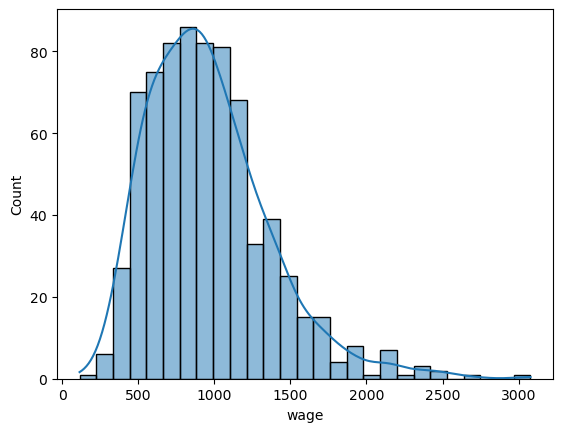

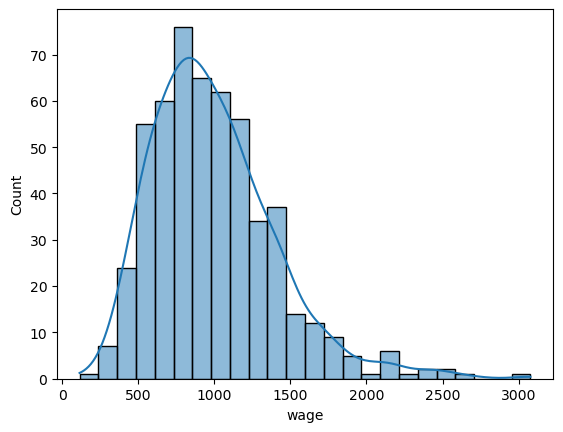

(531, 17)
(124, 17)


In [349]:
# ================================================================================
# Splitting training and test sets
# ================================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

data=pd.read_csv('WAGE2_2025_abridged.csv')

state=530088808+540338216+540527739+530800484+530356855 # replace this number with the sum of the student IDs for the members of your group

train = data.sample(frac=0.8, random_state=state)
test = data[data.index.isin(train.index)==False].copy() # Only for prediction

train=train.reset_index(drop=True)
test=test.reset_index(drop=True)
print(train.shape)
print(test.shape)
sns.histplot(train['wage'],kde=True)
plt.show()
#Check null values
train.isnull().any()
test.isnull().any()
#Drop null values
train=train.dropna()
test=test.dropna()
sns.histplot(train['wage'],kde=True)
plt.show()
print(train.shape) #training data original: 733, after cleaning = 531, change = 202
print(test.shape) #testing data original: 183, after cleaning = 124, change = 59

**3. Problem formulation**

Construct different multiple linear regression (MLR) models on the training data, consisting of 733 workers to examine the relationship between some of the independent variables, with years of experience and years of education as the base, and the monthly wage. Test the models' accuracy on the test data including of 183 workers.

There are a total of 15 independent variables in the dataset, including experience and education. Identify missing variables that potentially cause omitted variable bias (OVB) and incorporate them into the base model. Evaluate the fit of the new model and check for multicollinearity

Consider other potential methods of model formulations and independent variables that could improve the model's fit and predictive accuracy.

**4. Data cleaning**

We consider two approaches to data cleaning. The first one is to drop datas consist of null values only to the extent of dependent variables that we decide to use in the model formulation. This way, minimum number of data will be removed, which both helps remain as much data as possible, but still ensure consistency and integrity in the analysis. However, we find it challenging to figure out which dependent variables will be used in the formulation in the first stage. Therefore we come up with the second approach of dropping all datas that one or more of the dependent variables are null. This way, 202 datas of the train dataset and 59 datas of the test data set were removed. We acknowledge that reducing the size of the dataset significantly may impact its representativeness of the population, however as a trade-off, it would also prevent biases or inaccuracies in the regression results that the original one may have caused. Hence, the analysis ensures that model outputs are based fully on complete data, enhancing reliability of the insights into the relationships between these variables. For future research purposes, additional and complete data connection, together with research and analysis should be conducted to give timely and optimal findings of the study.

In [350]:
train.head()


,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
0,962,40,85,41,10,15,16,38,1,0,0,1,1,2.0,9.0,12.0,6.869014
2,894,40,104,35,18,7,10,35,1,0,1,0,7,8.0,9.0,8.0,6.795706
3,1250,40,92,42,16,10,11,32,0,0,1,1,1,1.0,12.0,10.0,7.130899
4,550,46,95,44,12,18,15,35,1,0,0,1,1,1.0,12.0,11.0,6.309918
5,600,40,114,36,16,5,4,30,1,0,1,1,2,1.0,12.0,12.0,6.396930


In [351]:
test.head()

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
1,1318,38,119,24,16,7,2,28,1,0,0,1,3,1.0,10.0,10.0,7.183871
2,1792,40,118,47,16,9,9,34,1,0,0,1,1,1.0,12.0,12.0,7.491087
7,1274,40,106,35,13,11,12,31,1,0,0,1,0,1.0,15.0,12.0,7.149917
8,692,40,108,48,12,21,11,38,1,0,0,1,3,1.0,8.0,7.0,6.539586
10,808,60,109,47,13,14,12,38,1,0,0,1,2,2.0,12.0,10.0,6.694562


In [352]:
#EDA after cleaning
train.describe().round(2)


,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
count,531.00,531.00,531.00,531.00,531.00,531.00,531.00,531.00,531.0,531.00,531.00,531.00,531.00,531.00,531.00,531.00,531.00
mean,995.62,44.08,103.01,36.34,13.73,11.41,6.98,33.00,0.9,0.08,0.33,0.72,2.86,2.20,10.89,10.27,6.82
std,409.45,7.25,14.77,7.56,2.25,4.26,4.96,3.11,0.3,0.26,0.47,0.45,2.26,1.51,2.80,3.30,0.41
min,115.00,25.00,54.00,13.00,9.00,1.00,0.00,28.00,0.0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,4.74
25%,700.00,40.00,95.00,32.00,12.00,8.00,2.00,30.00,1.0,0.00,0.00,0.00,1.00,1.00,9.00,8.00,6.55
50%,929.00,40.00,104.00,37.00,13.00,11.00,7.00,33.00,1.0,0.00,0.00,1.00,2.00,2.00,12.00,11.00,6.83
75%,1201.50,48.00,113.00,42.00,16.00,15.00,10.00,36.00,1.0,0.00,1.00,1.00,4.00,3.00,12.00,12.00,7.09
max,3078.00,80.00,145.00,56.00,18.00,22.00,22.00,38.00,1.0,1.00,1.00,1.00,14.00,10.00,18.00,18.00,8.03


In [353]:
test.describe().round(2)

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
count,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00
mean,957.16,44.08,100.48,35.73,13.55,11.23,7.94,32.84,0.90,0.09,0.27,0.70,2.69,2.02,10.54,10.26,6.78
std,401.36,6.83,14.22,7.55,2.16,4.23,5.15,2.89,0.31,0.29,0.44,0.46,2.08,1.29,2.94,3.25,0.43
min,200.00,32.00,66.00,19.00,9.00,1.00,0.00,28.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,3.00,5.30
25%,687.25,40.00,91.00,30.00,12.00,8.00,3.00,30.00,1.00,0.00,0.00,0.00,1.00,1.00,8.00,8.00,6.53
50%,943.50,40.00,99.50,36.50,12.00,11.00,8.00,32.50,1.00,0.00,0.00,1.00,2.00,2.00,12.00,10.00,6.85
75%,1154.25,48.00,109.25,41.00,16.00,14.25,12.00,35.00,1.00,0.00,1.00,1.00,3.00,2.00,12.00,12.00,7.05
max,2771.00,70.00,134.00,49.00,18.00,21.00,20.00,38.00,1.00,1.00,1.00,1.00,13.00,7.00,18.00,18.00,7.93


After cleaning the data by removing all data including null values, we retained 530 observations for the training data and 125 observations for the test data. To gain insights into our objectives to achieve our goals of examining the relationship between years of education, years of experience and monthly wage, and to build an optimal model to forecast income, and to determine whether education or experience should be focused on for predicting income. 

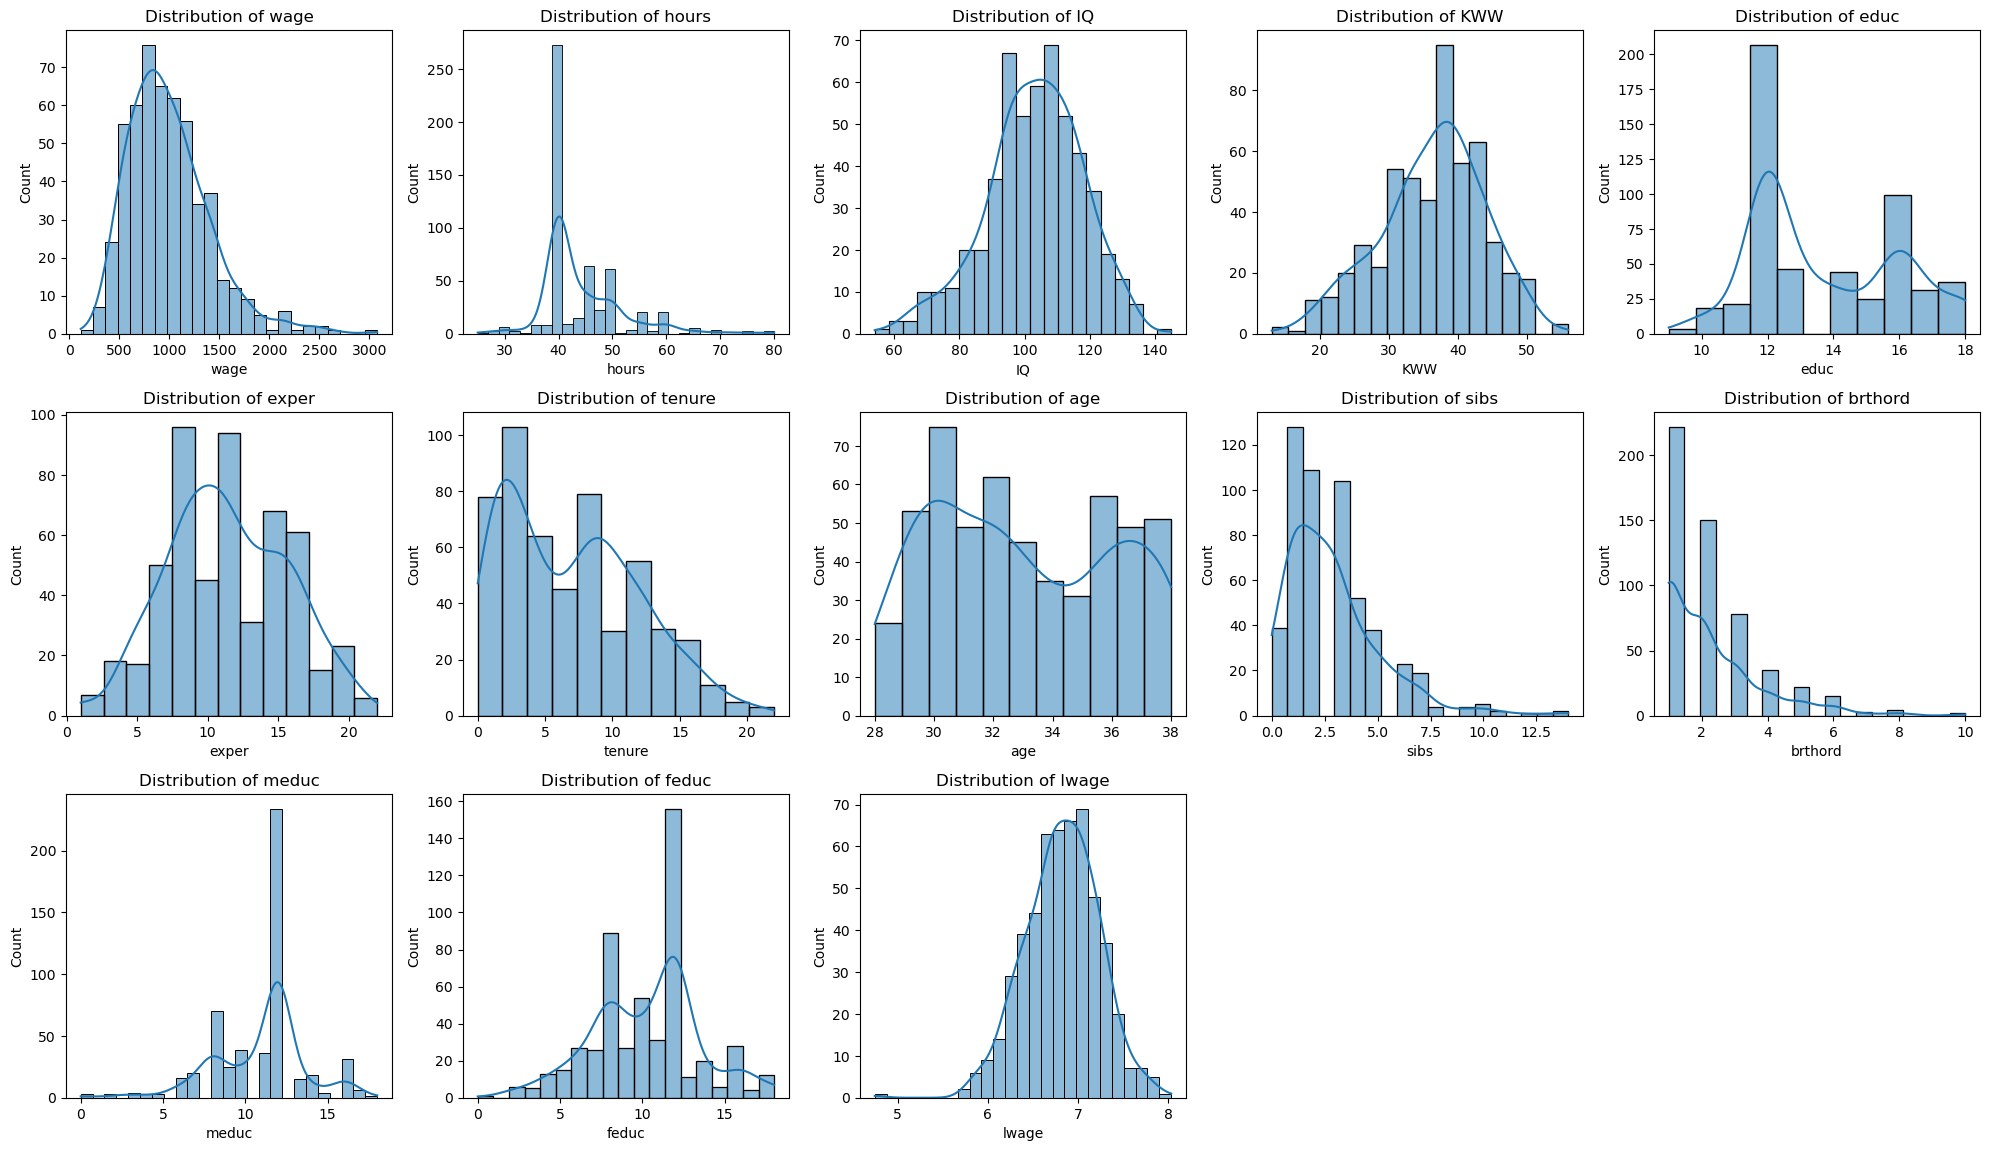

In [354]:
#Distribution of numerical variables
variables = ['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','sibs','brthord','meduc','feduc','lwage']
n_cols=5
n_rows=4
fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,15))
axes=axes.flatten()
for i, var in enumerate(variables):
    sns.histplot(train[var],kde=True,ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
for j in range (i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

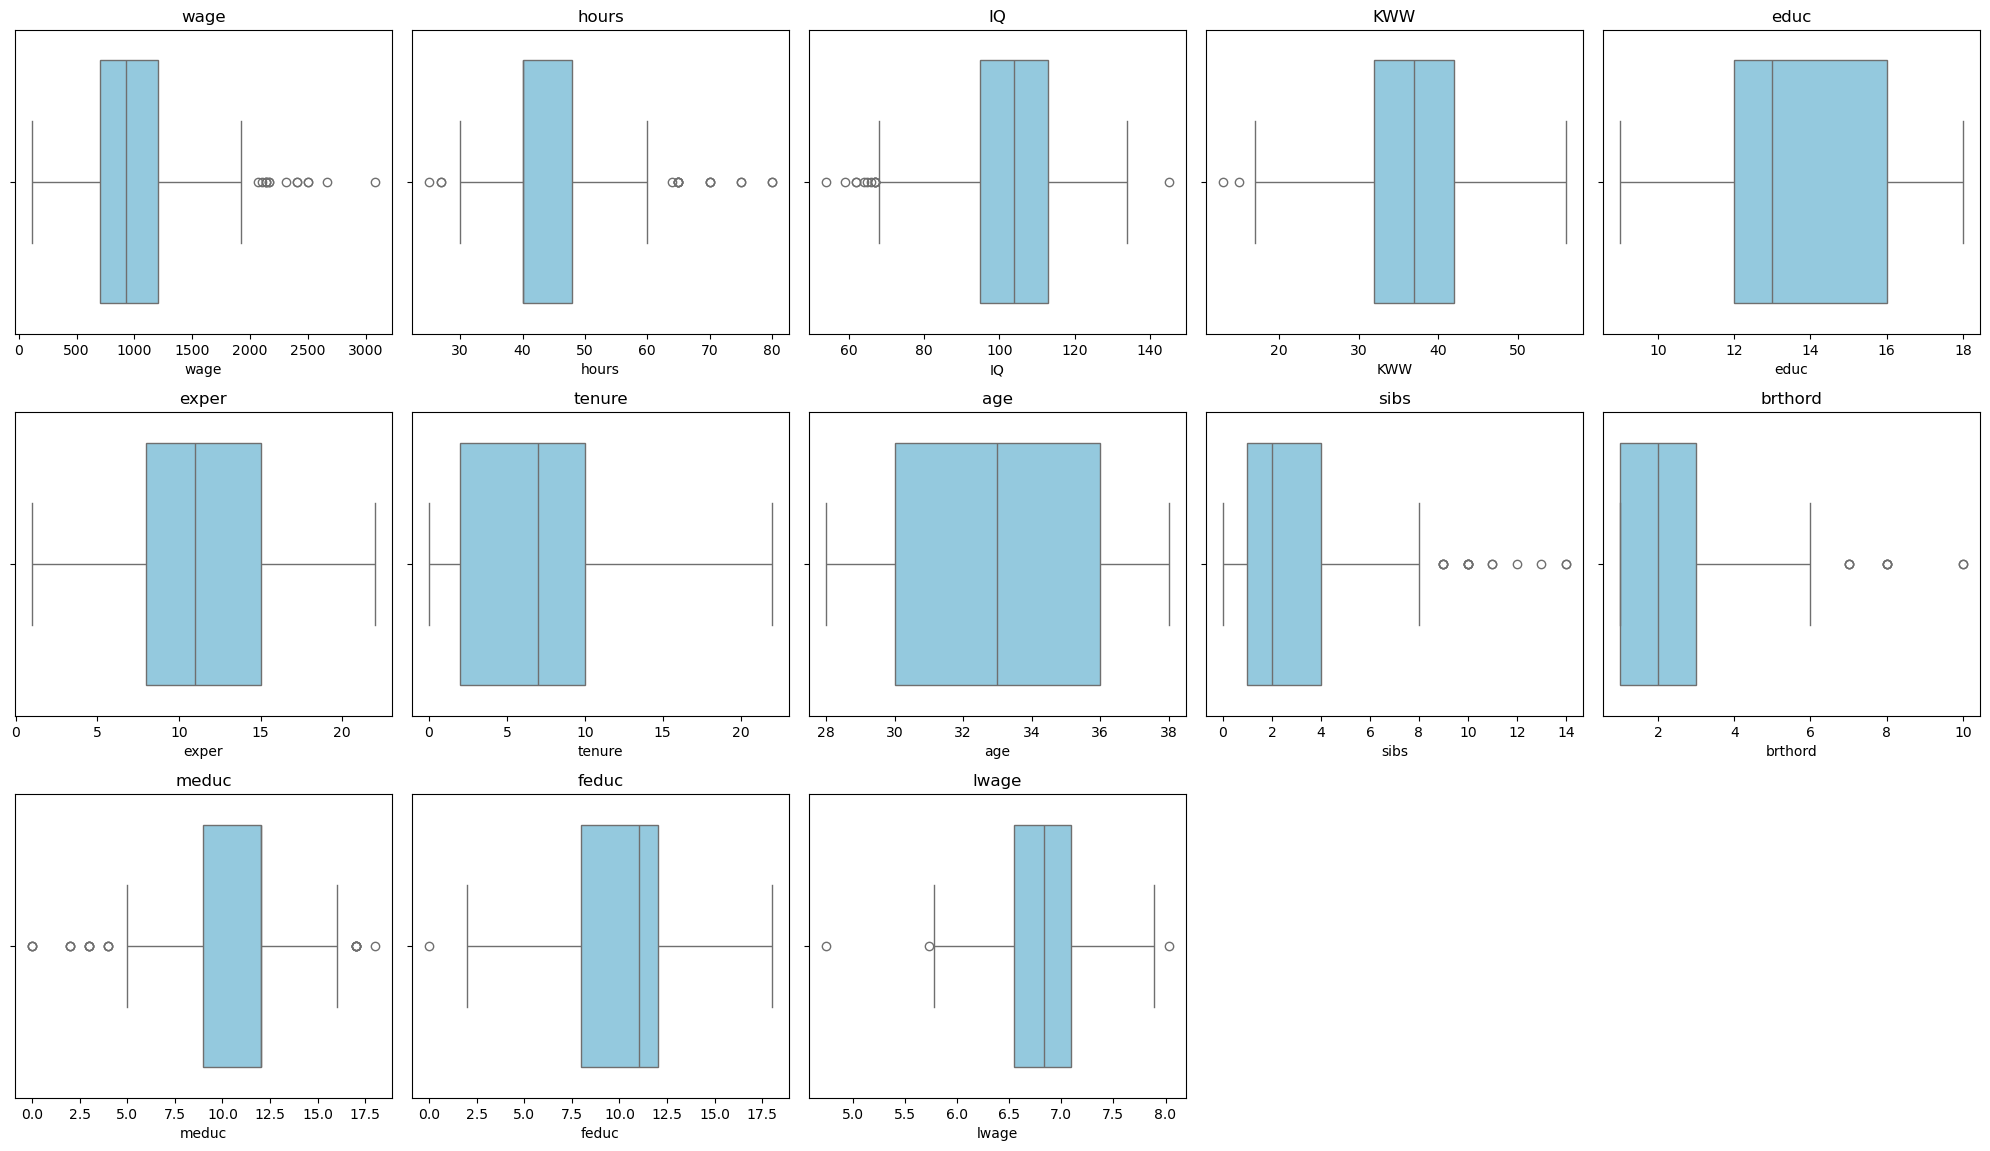

In [355]:
#boxplots of numerical variables
variables = ['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','sibs','brthord','meduc','feduc','lwage']
n_cols=5
n_rows=4
fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,15))
axes=axes.flatten()
for i, var in enumerate(variables):
    sns.boxplot(x=train[var],ax=axes[i],color='skyblue')
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel('')
for j in range (i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

The distribution of wage skewed heavily to the right, indicating the distribution of most individuals earning around the lower range, and a few high-earners that push the tail. Looking at the histogram of lwage where approximately normal distribution incurs, this might suggest the use of lwage for normalisation in future moelling stages. 

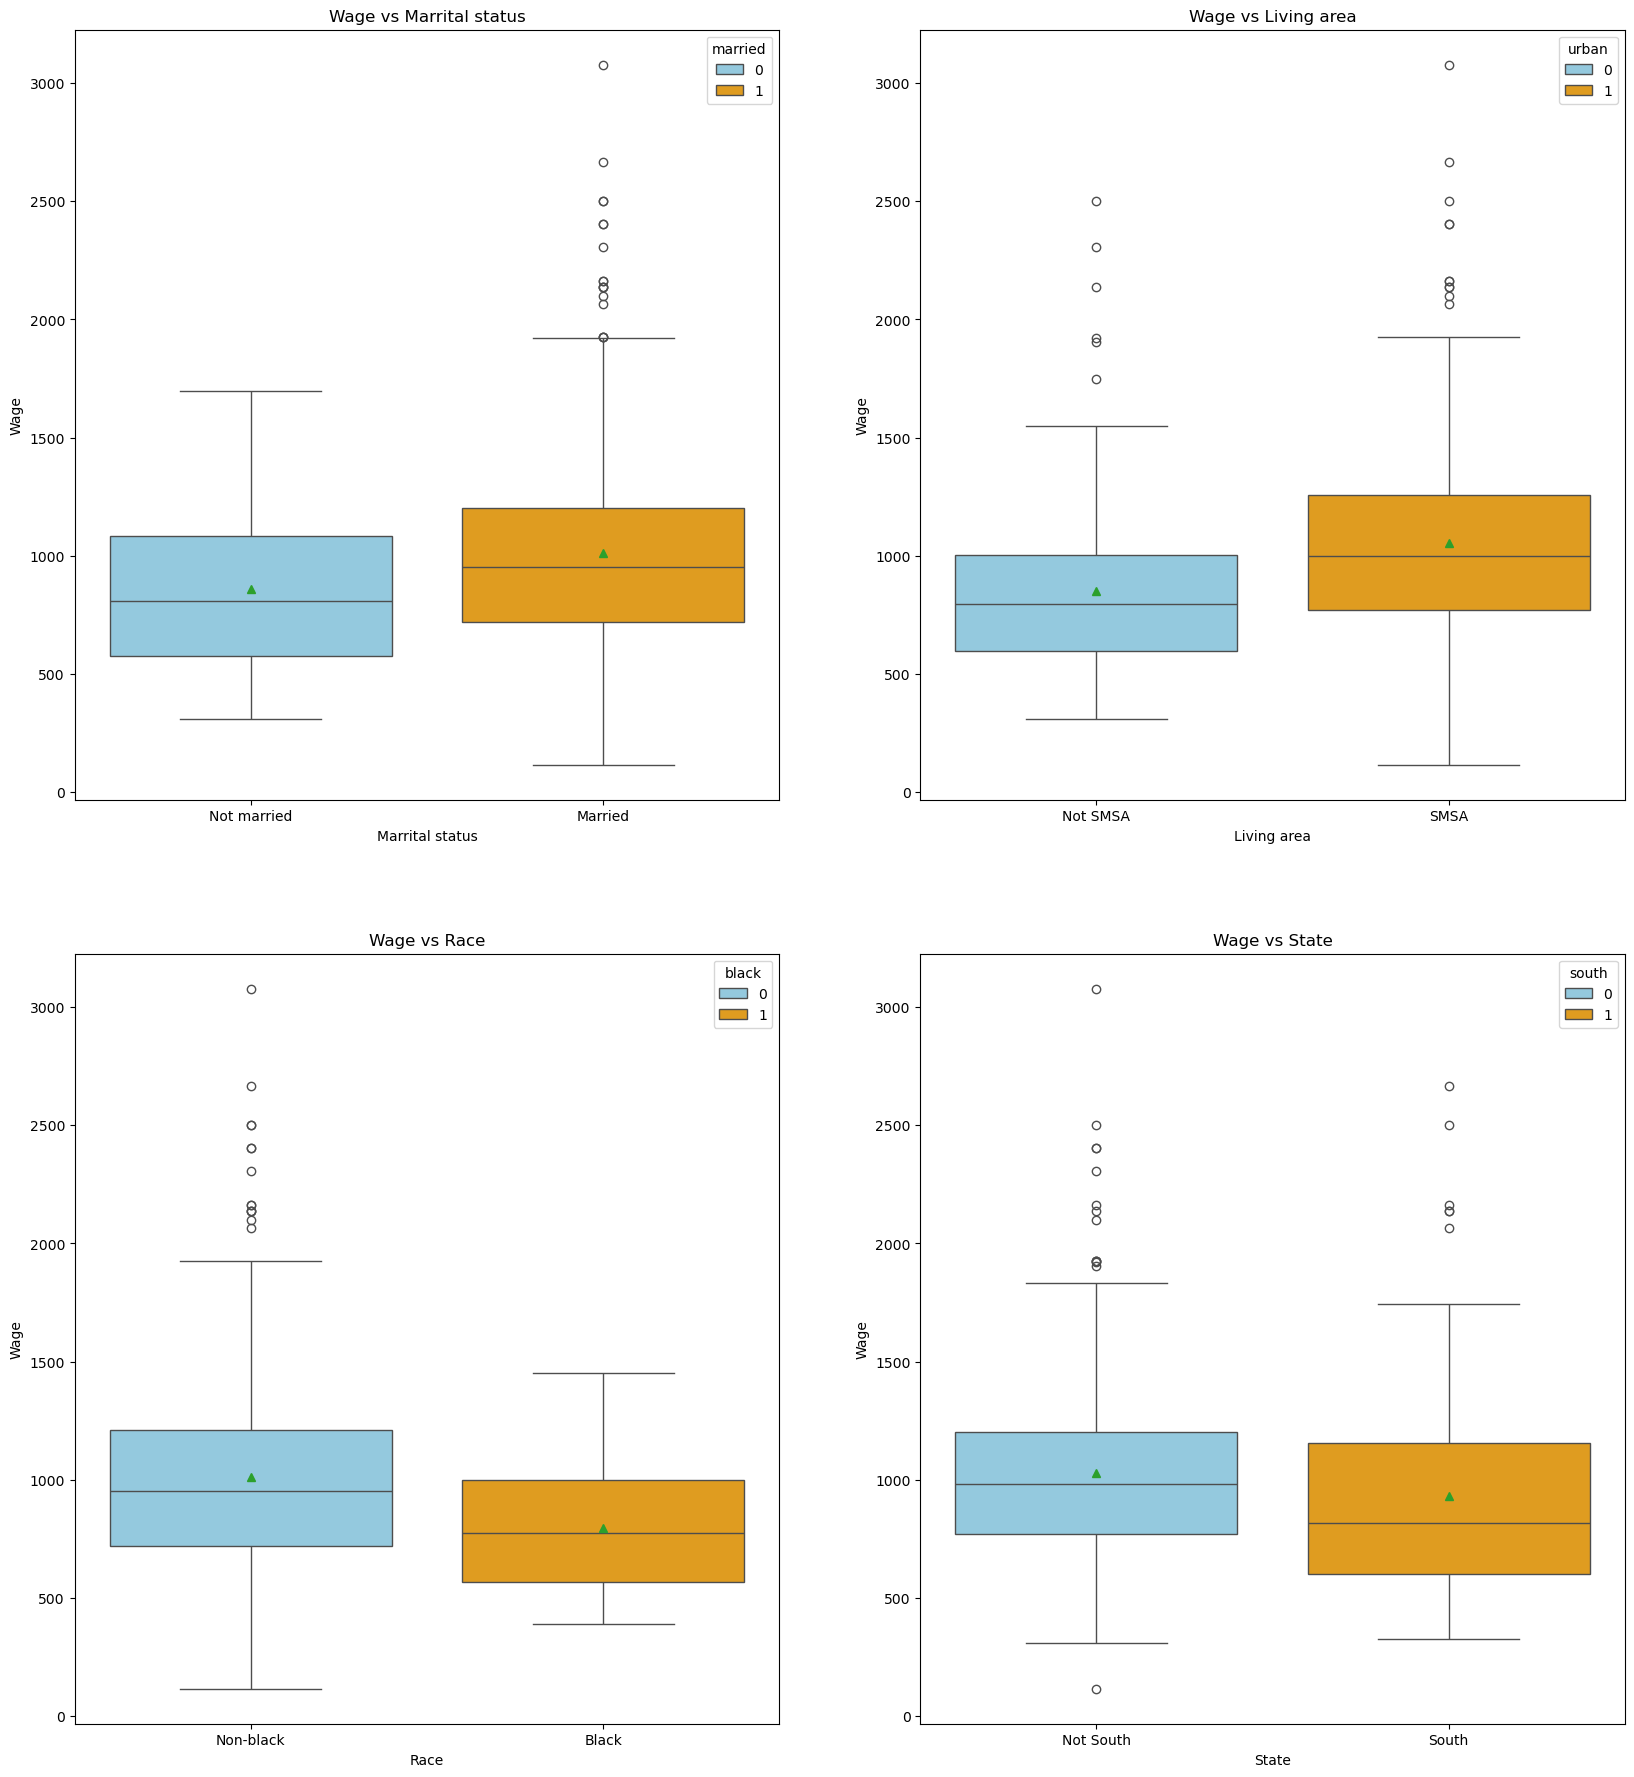

In [356]:
#side-by-side boxplots of wages vs categorical variabes
fig,ax=plt.subplots(2,2,figsize=(20,22))
sns.boxplot(x=train['married'],y=train['wage'],hue=train['married'],palette=['skyblue','orange'],ax=ax[0,0],showmeans=True)
ax[0,0].set_title('Wage vs Marrital status')
ax[0,0].set_xlabel('Marrital status')
ax[0,0].set_ylabel('Wage')
ax[0,0].set_xticks([0,1],['Not married','Married'])
sns.boxplot(x=train['urban'],y=train['wage'],hue=train['urban'],palette=['skyblue','orange'],ax=ax[0,1],showmeans=True)
ax[0,1].set_title('Wage vs Living area')
ax[0,1].set_xlabel('Living area')
ax[0,1].set_ylabel('Wage')
ax[0,1].set_xticks([0,1],['Not SMSA','SMSA'])
sns.boxplot(x=train['black'],y=train['wage'],hue=train['black'],palette=['skyblue','orange'],ax=ax[1,0],showmeans=True)
ax[1,0].set_title('Wage vs Race')
ax[1,0].set_xlabel('Race')
ax[1,0].set_ylabel('Wage')
ax[1,0].set_xticks([0,1],['Non-black','Black'])
sns.boxplot(x=train['south'],y=train['wage'],hue=train['south'],palette=['skyblue','orange'],ax=ax[1,1],showmeans=True)
ax[1,1].set_title('Wage vs State')
ax[1,1].set_xlabel('State')
ax[1,1].set_ylabel('Wage')
ax[1,1].set_xticks([0,1],['Not South','South'])
plt.show()

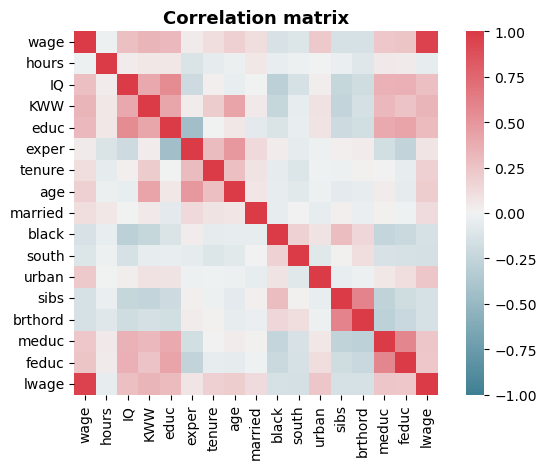

In [357]:
fig,ax=plt.subplots()
variables=['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','married','black','south','urban','sibs','brthord','meduc','feduc','lwage']
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(train[variables].corr(), vmax=1, vmin=-1, center=0, square=True, ax=ax, cmap=cmap)
ax.set_title('Correlation matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

The correlation heat-map illustrates some strong positive and negative correlations between variables in this dataset. Positive correlations with the response variable wage exist for IQ, KWW, educ, feduc, urban. Years of experience, however, barely correlated with the variable wage. 



In [358]:
train[variables].corr().round(2)

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
wage,1.00,-0.02,0.27,0.33,0.31,0.04,0.12,0.18,0.11,-0.14,-0.11,0.22,-0.15,-0.14,0.23,0.25,0.96
hours,-0.02,1.00,0.04,0.06,0.06,-0.12,-0.06,-0.03,0.06,-0.04,-0.02,-0.00,-0.03,-0.10,0.05,0.04,-0.05
IQ,0.27,0.04,1.00,0.40,0.55,-0.20,0.02,-0.04,-0.01,-0.29,-0.14,0.03,-0.24,-0.18,0.35,0.36,0.28
KWW,0.33,0.06,0.40,1.00,0.42,0.03,0.20,0.42,0.05,-0.24,-0.05,0.09,-0.25,-0.16,0.31,0.26,0.33
educ,0.31,0.06,0.55,0.42,1.00,-0.44,-0.00,0.05,-0.07,-0.12,-0.04,0.08,-0.20,-0.18,0.39,0.42,0.30
exper,0.04,-0.12,-0.20,0.03,-0.44,1.00,0.29,0.49,0.13,0.03,-0.06,-0.02,0.02,0.04,-0.18,-0.26,0.07
tenure,0.12,-0.06,0.02,0.20,-0.00,0.29,1.00,0.27,0.08,-0.06,-0.11,-0.01,-0.02,0.02,0.00,-0.05,0.18
age,0.18,-0.03,-0.04,0.42,0.05,0.49,0.27,1.00,0.07,-0.05,-0.08,-0.02,-0.07,-0.05,0.04,-0.06,0.20
married,0.11,0.06,-0.01,0.05,-0.07,0.13,0.08,0.07,1.00,-0.05,0.00,-0.05,0.02,-0.04,0.01,-0.01,0.12
black,-0.14,-0.04,-0.29,-0.24,-0.12,0.03,-0.06,-0.05,-0.05,1.00,0.18,0.08,0.28,0.15,-0.24,-0.21,-0.15


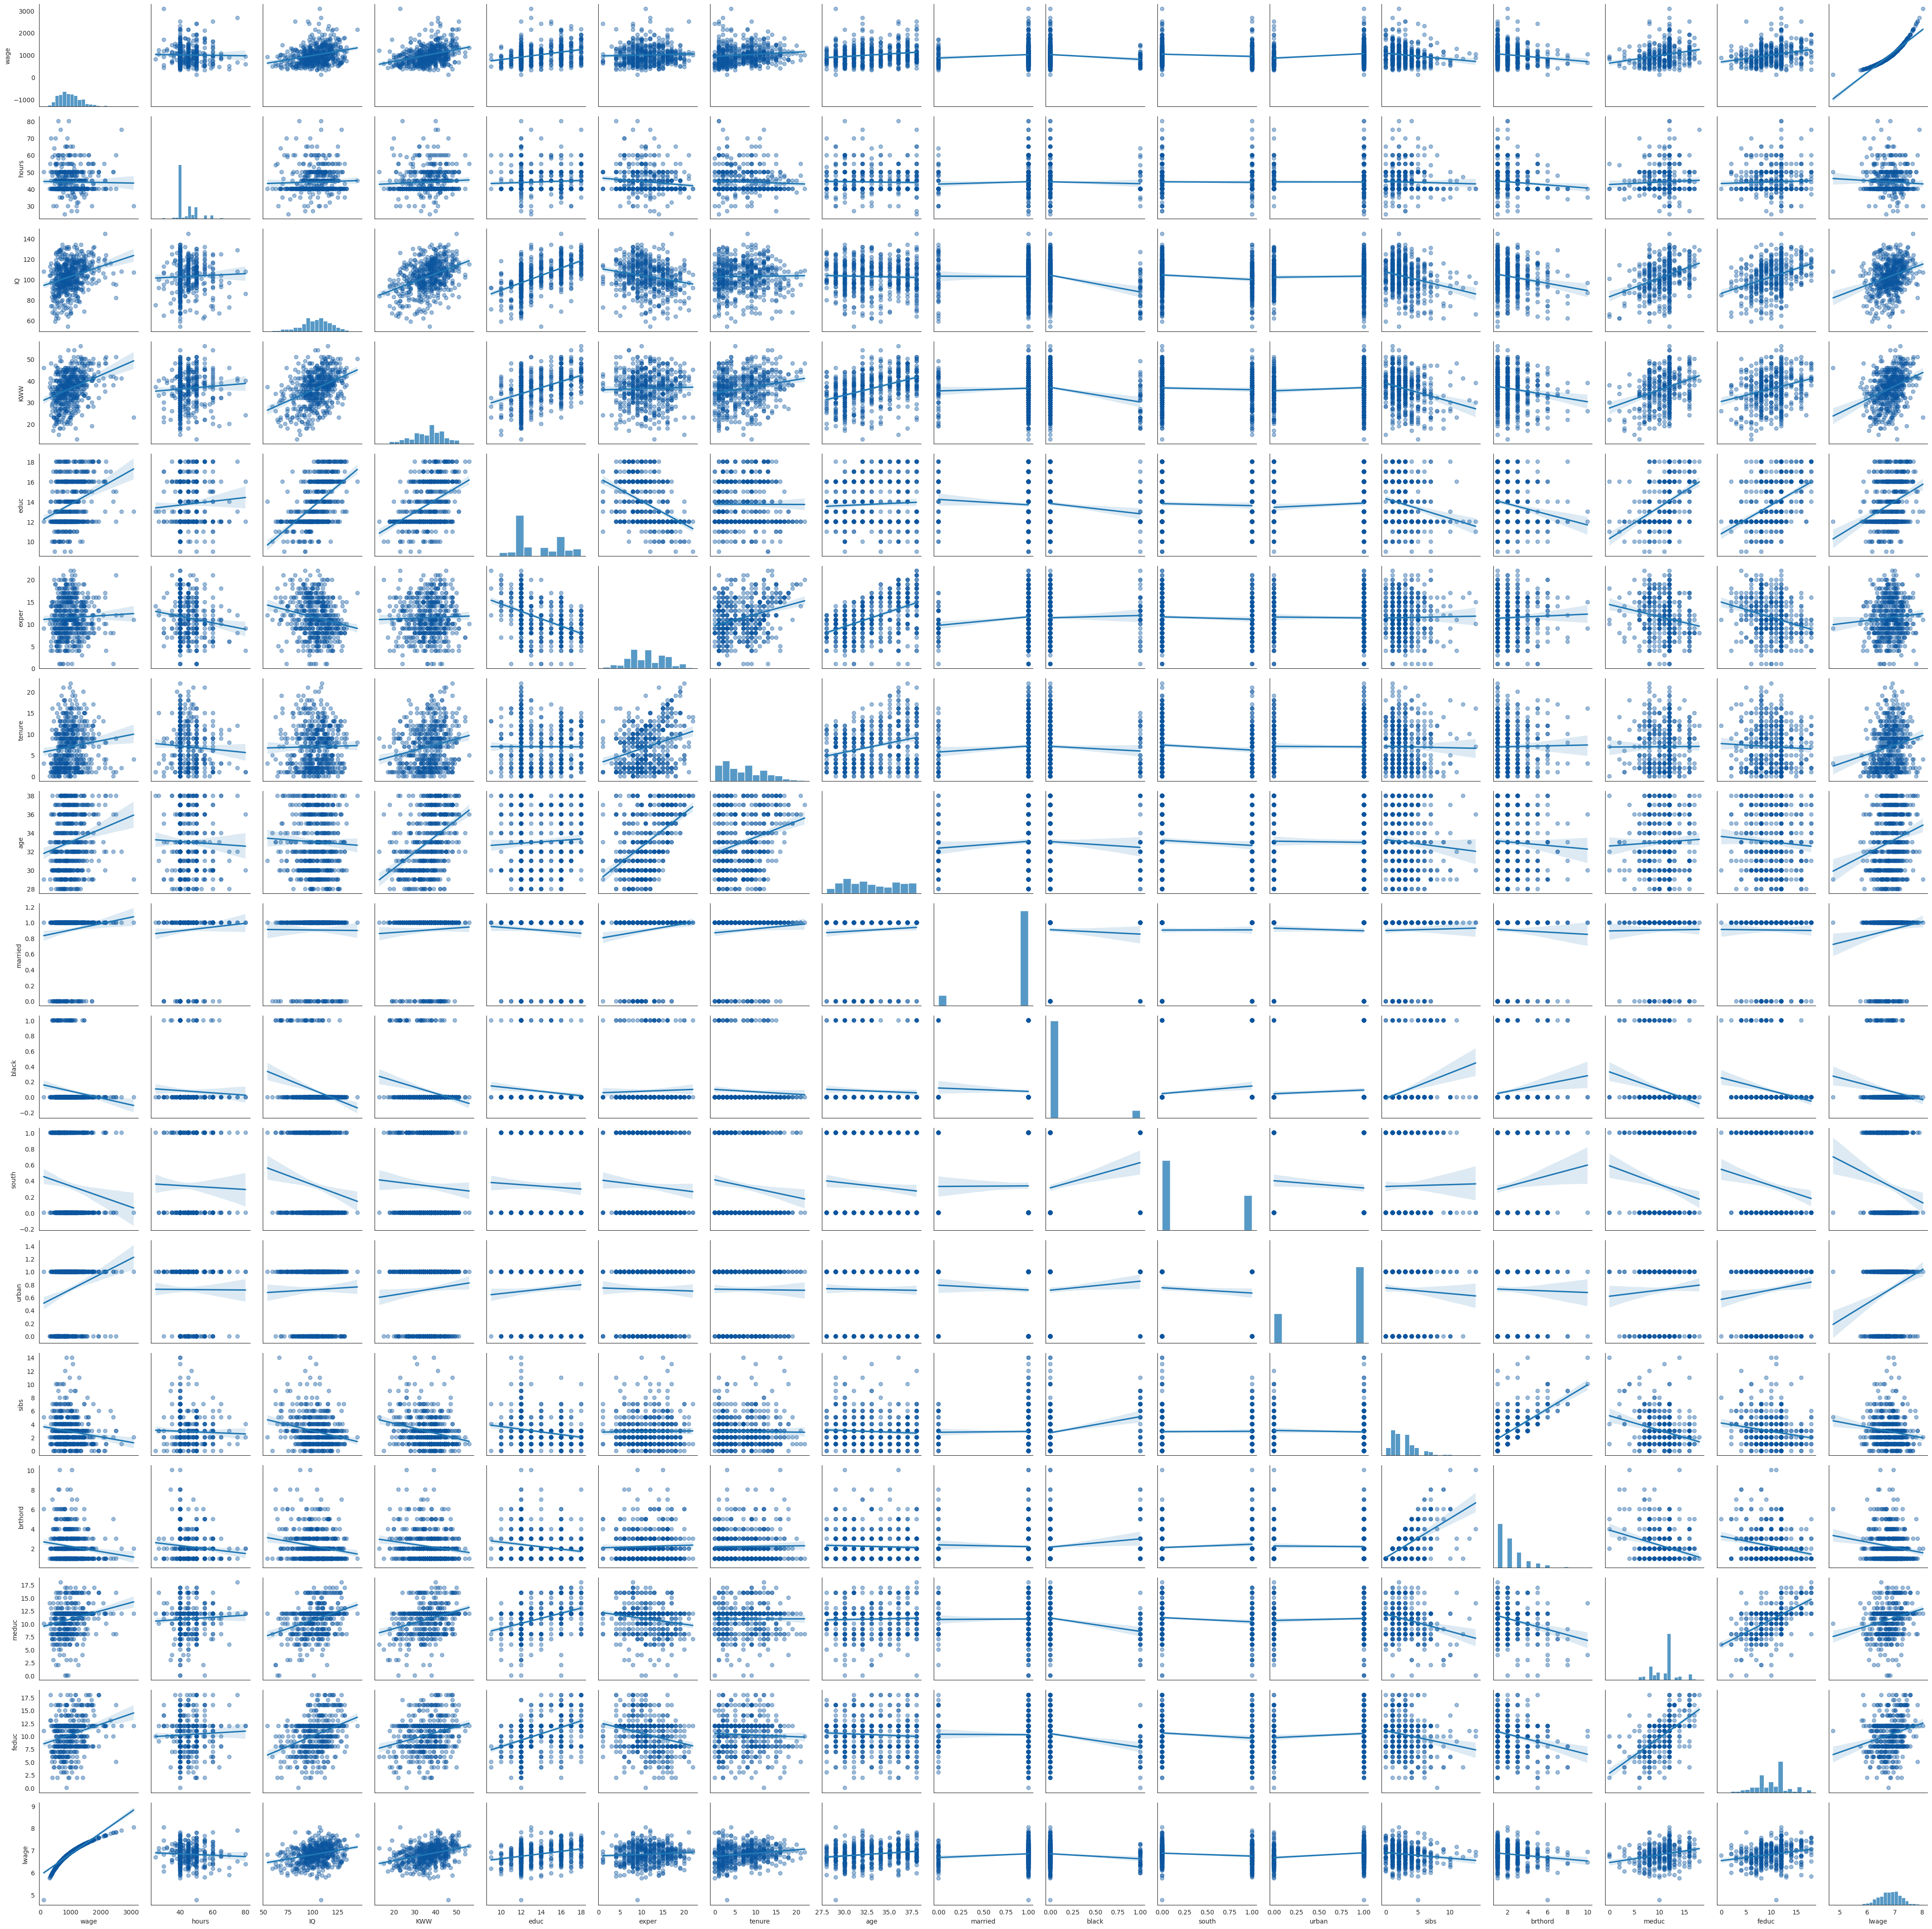

In [359]:
with sns.axes_style('white'):
    g=sns.pairplot(train[variables], kind='reg',
                   plot_kws={'scatter_kws' :{'color': sns.color_palette('Blues')[-1], 'alpha': 0.4}})
plt.tight_layout()
g.fig.savefig('DM-pairplot.png', dpi=300)
plt.show()

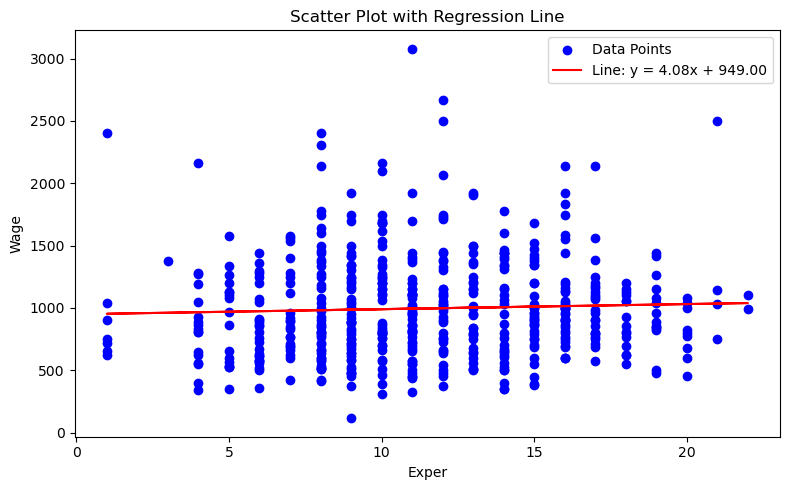

In [360]:
m, c = np.polyfit(train['exper'], train['wage'], 1)  # 1 means linear

# Generate y values for the regression line
wage_pred = m * train['exper'] + c

# Plot scatter and regression line
plt.figure(figsize=(8, 5))
plt.scatter(train['exper'], train['wage'], color='blue', label='Data Points')
plt.plot(train['exper'], wage_pred, color='red', label=f'Line: y = {m:.2f}x + {c:.2f}')
plt.title('Scatter Plot with Regression Line')
plt.xlabel('Exper')
plt.ylabel('Wage')
plt.legend()
plt.tight_layout()
plt.show()


Clear positive relationships exist between wage and variables such as IQ, KWW, and education. These relationships appear approximately linear and relatively strong, suggesting these variables may be important predictors in modeling wage. For example, as education increases, average wages also tend to rise, which aligns with economic expectations.

However, some relationships are more complex. The relationship between wage and experience (exper) flattern after a certain point, suggesting a potential non-linear trend. This plateau effect implies that while early years of experience may boost wages, the marginal gains diminish with time. A similar pattern is observed with tenure, when the upward trend is present but less clearly defined, indicating the need for potential modeling with squared or interaction terms to better capture the relationship. 

Several categorical variables such as married, black, south, and urban show distinct groupings in wage. For example, married individuals tend to have slightly higher wages, while the black and south categories show a mild negative association. These groupings suggest tht such variables might influence wages through interaction effects or differences in variance rather than through mean differences alone. 

Background variables like sibs and birthord show weak negative relationships with wage. This could indicate that individuals from larger families or with later birth order positions might receive fewer resources or opportunities during development, but these effects appear small and unlikely to serve as strong predictors in isolation. 

Regarding the parental education variables (meduc and feduc), the relationships with wage are present but weak. This suggests background factors may have some influence, potentially due to better access to educational resources or inherited values regarding education and ambition, though they are not as predictive as an individual's own education or ability (as proxied by IQ and KWW).

In terms of relationships between the predictors, no extremely strong correlations are observed that would suggest problematic multicollinearity. While there are some moderate associations (e.g., between educ and IQ, or tenure and age), none are strong enough to cause immediate concern for variance inflation in the regression model. At this stage, multicollinearity does not appear to be a major issue.

In [361]:
train[['wage','educ','exper']].describe().round(2)

,wage,educ,exper
count,531.00,531.00,531.00
mean,995.62,13.73,11.41
std,409.45,2.25,4.26
min,115.00,9.00,1.00
25%,700.00,12.00,8.00
50%,929.00,13.00,11.00
75%,1201.50,16.00,15.00
max,3078.00,18.00,22.00


In [362]:
model = smf.ols(formula='wage ~ hours +  IQ + KWW + educ + exper + tenure + age + married + black + south + urban + sibs + brthord + meduc + feduc', data=train)
reg = model.fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     10.70
Date:                Thu, 29 May 2025   Prob (F-statistic):           1.22e-22
Time:                        19:55:26   Log-Likelihood:                -3874.8
No. Observations:                 531   AIC:                             7782.
Df Residuals:                     515   BIC:                             7850.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -594.3412    260.485     -2.282      0.023   -1106.085     -82.597
hours         -2.2238      2.215     -1.004      0.316      -6.576       2.128
IQ             1.9545      1.405      1.391      0.165      -0.807       4.716
KWW            6.6200      2.785      2.377      0.018       1.149      12.091
educ          37.9593     10.413      3.646      0.000      17.503      58.416
exper         12.1049      5.264      2.300      0.022       1.763      22.447
tenure         2.5618      3.434      0.746      0.456      -4.185       9.308
age            5.9827      6.944      0.862      0.389      -7.659      19.625
married      146.8417     54.020      2.718      0.007      40.716     252.968
black        -67.0372     66.932     -1.002      0.317    -198.531      64.457
south        -27.3144     35.273     -0.774      0.439     -96.611      41.982
urban        170.7131     36.030      4.738      0.000      99.929     241.497
sibs           1.5727      9.227      0.170      0.865     -16.555      19.700
brthord      -11.2680     13.480     -0.836      0.404     -37.750      15.214
meduc          3.2926      7.307      0.451      0.652     -11.062      17.648
feduc         11.1663      6.228      1.793      0.074      -1.070      23.402
==============================================================================
Omnibus:                      164.611   Durbin-Watson:                   1.823
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              630.335
Skew:                           1.378   Prob(JB):                    1.33e-137
Kurtosis:                       7.571   Cond. No.                     2.08e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.08e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The effects of each variable can be summarized as:::

Keeping all other variables constant, an increase of 1 average weekly hour is associated with an average decrease in the wage of 2.22 dollars.

Keeping all other variables constant, an increase of 1 IQ score is associated with an average increase in the wage of 1.95 dollars.

Keeping all other variables constant, an increase of 1 knowledge of world work score is associated with an average increase in the wage of 6.62 dollars.

Keeping all other variables constant, an increase of 1 year of education is associated with an average increase in the wage of 37.95 dollars.

Keeping all other variables constant, an increase of 1 year of experience is associated with an average increase in the wage of 12.1 dollars.

Keeping all other variables constant, an increase of 1 year with current employer is associated with an average decrease in the wage of 2.56 dollars.

Keeping all other variables constant, an increase of 1 age is associated with an average increase in the wage of 5.98 dollars.

Keeping all other variables constant, married people earns 146.84 dollars on average more than others. 

Keeping all other variables constant, black people earns 67.03 dollars on average less than others. 

Keeping all other variables constant, south people earns 27.31 dollars on average less than others. 

Keeping all other variables constant, urban people earns 170.71 dollars on average more than others. 

Keeping all other variables constant, an increase of 1 sibling is associated with an average increase in the wage of 1.57 dollars.

Keeping all other variables constant, an increase of 1 birth order is associated with an average decrease in the wage of 11.27 dollars.

Keeping all other variables constant, an increase of 1 year of mother's education is associated with an average increase in the wage of 3.29 dollars.

Keeping all other variables constant, an increase of 1 year of father's education is associated with an average increase in the wage of 11.17 dollars.


In [363]:
reg.mse_resid**0.5

362.69230272797444

In [364]:
model_base = smf.ols(formula='wage ~ educ + exper', data=train) 
regbase = model_base.fit()
regbase.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     41.43
Date:                Thu, 29 May 2025   Prob (F-statistic):           1.93e-17
Time:                        19:55:26   Log-Likelihood:                -3908.1
No. Observations:                 531   AIC:                             7822.
Df Residuals:                     528   BIC:                             7835.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -264.3942    142.291     -1.858      0.064    -543.921      15.133
educ          74.1534      8.201      9.042      0.000      58.043      90.263
exper         21.2275      4.323      4.910      0.000      12.735      29.720
==============================================================================
Omnibus:                      135.138   Durbin-Watson:                   1.867
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              389.743
Skew:                           1.220   Prob(JB):                     2.34e-85
Kurtosis:                       6.416   Cond. No.                         155.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

As in the full model, the variable educ is positively related to wage, after accounting for the effect of exper. Again, exper is positively related to wage, after accounting for the effect of educ. The effects of each variable can be summarized as:

Keeping years of work excperience constant, an increase of 1 year of education is associated with an average increase in the wage of 74.15 dollars.
Keeping years of education constant, an increase of 1 year of experience is associated with an average increase in the wage of 21.23 dollars.

It is also noticeable that these estimates, though of the same sign, are quite different to their respective etimates in the full model. This could be evidence of some omitted variable bias (OVB) in this reduced model, for both variables. We consider this in more detail in part (i).


In [365]:
residbase=regbase.resid
fitbase=regbase.fittedvalues
regbase.mse_resid**0.5

381.38333895467895

In [366]:
1/(1-0.460066**2)

1.2684893812795168

The full model has $R^2 = 0.238$, $R^2_{adj} = 0.215$ and SER = $362.69$ dollars.
The reduced model has $R^2 = 0.136$, $R^2_{adj} = 0.132$ and SER = $381.38$ dollars.

The full model captures about $22\%$ of the variation in wages, with a typical prediction error of about $\$362$. The reduced model captures about $13\%$ of the variation in wages, with a typical prediction error of about $\$381$. Clearly, both models are pretty strong fits to the data, but the full model is the strongest fit between the two, capturing about $9$ percentage point more variation in wages and reducing the prediction error by about $\$19$.   

The variance inflation can be measured by the $R^2$ in the regression of one regressor on the other. Both equal to $\frac{1}{1-r^2}$, where $r$ is the correlation between educ and exper, as calculated above, equal 1.27. This is not a large number -- the usual threshold for the presence of a multicollinearity problem is 5.


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


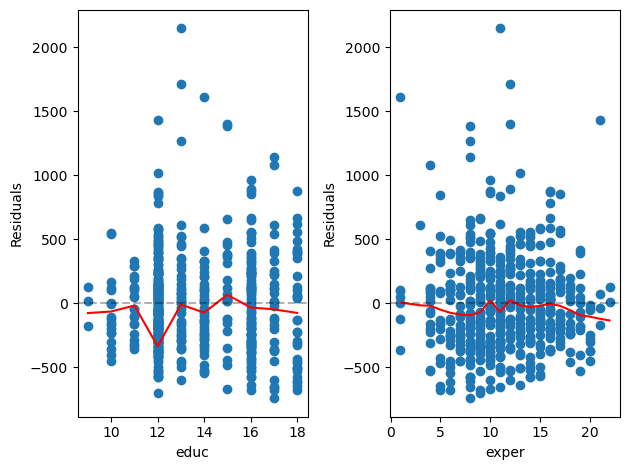

In [367]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

lowess = sm.nonparametric.lowess

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# First plot (educ vs residuals)
mask1 = (
    ~regbase.resid.isna() & 
    ~train['educ'].isna() & 
    np.isfinite(regbase.resid) & 
    np.isfinite(train['educ'])
)
ax1.scatter(train['educ'], regbase.resid)
z1 = lowess(regbase.resid[mask1], train['educ'][mask1], frac=1./5)
ax1.plot(z1[:, 0], z1[:, 1], 'red')
ax1.set_xlabel('educ')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black', alpha=0.3, linestyle='--')

# Second plot (exper vs residuals)
mask2 = (
    ~regbase.resid.isna() & 
    ~train['exper'].isna() & 
    np.isfinite(regbase.resid) & 
    np.isfinite(train['exper'])
)
ax2.scatter(train['exper'], regbase.resid)
z2 = lowess(regbase.resid[mask2], train['exper'][mask2], frac=1./5)
ax2.plot(z2[:, 0], z2[:, 1], 'red')
ax2.set_xlabel('exper')
ax2.set_ylabel('Residuals')
ax2.axhline(color='Black', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

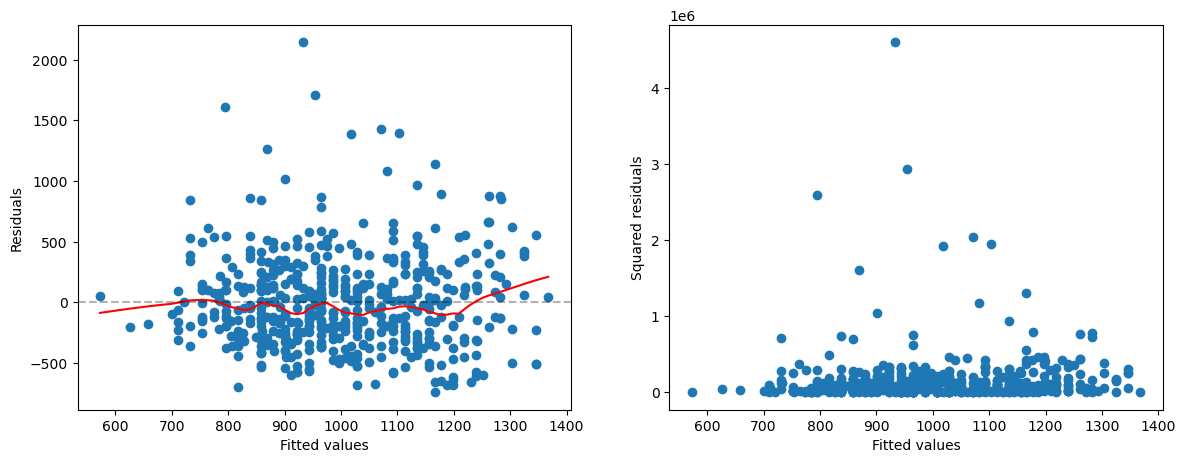

In [368]:
#Residual and squared residual plots against fitted values
fig = plt.figure(figsize=(14,5))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)
ax1.scatter(regbase.fittedvalues,regbase.resid)
z1=lowess(regbase.resid,regbase.fittedvalues,frac=1./5)
ax1.plot(z1[:,0],z1[:,1],'red')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black',alpha=0.3,linestyle='--')
residbase2=regbase.resid**2
ax2.scatter(regbase.fittedvalues,residbase2)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Squared residuals')
plt.show()

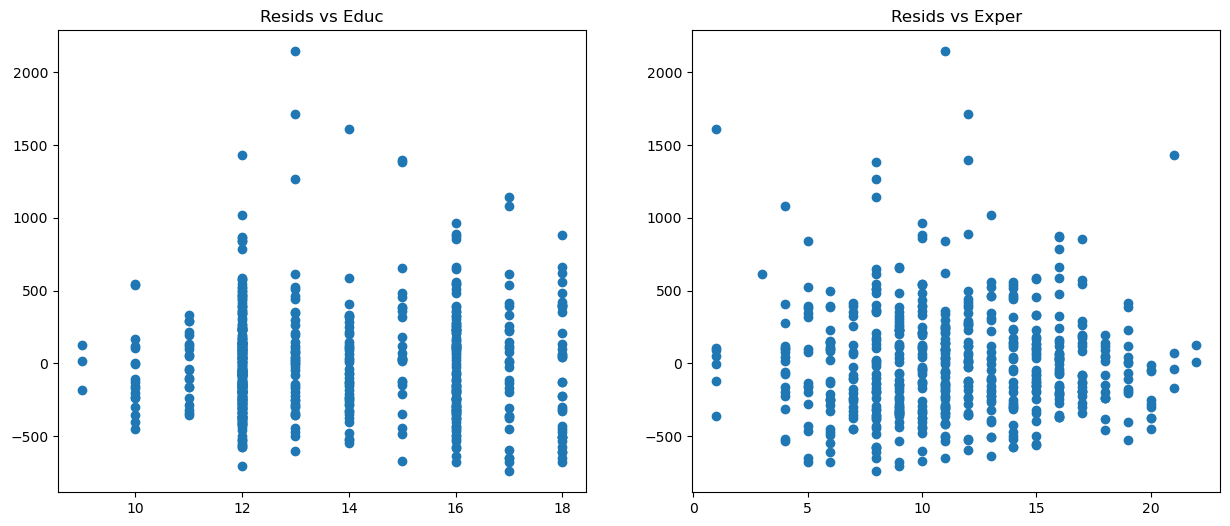

In [369]:
fig = plt.figure(figsize=(15,6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
ax1.scatter(train['educ'],residbase)
ax1.set_title("Resids vs Educ")
ax2.scatter(train['exper'], residbase)
ax2.set_title("Resids vs Exper")
plt.show()

The residuals vs fitted values plot shows no clear pattern in the mean, i.e. the errors seem to average close to 0 for most fitted values, as confirmed by the LOESS curve (apart from a mild dip in the middle). The residuals vs each predictor show that **E**$(e|X) = 0$ appears to hold for most value of $X$. Thus, the linear model seems a reasonable fit for the wage data.

However, there is evidence that the variance of residuals increases slightly for higher fitted values. This is visible in the squared residuals plot, where spread is larger at the extremes. Hence, the assumption of constant variance may not hold, and inference may benefit from using heteroskedasticity-robust standard errors.

The scatter plots of wage against each predictor (in blue), overlaid with fitted values (in orange), offer additional insights:

For **education**, the orange predicted values track the increasing trend in wage with rising education, though they tend to underpredict for higher earners.

For **experience**, a similar pattern is observed: predictions follow the general shape of the data but fail to capture some curvature or variance at higher experience levels. These plots suggest that the model captures the main linear trend well, though it might benefit from polynomial or interaction terms for more accuracy. 

Regarding the other MLR LSA:

**LSA 2** requires **E**$(e|X) = 0$. While the resiual plots support this assumption, it may still be violated due to **omitted variable bias**. For instance, IQ and KWW, which show a positive correlation with wage and likely correlate with educ, are not included in this model. This may bias the coefficient estimates for educ. 

**LSA 3** assumes that the observations are i.i.d. As we lack temporal or cluster structure in the data, we proceed under this assumption.

**LSA 4** concerns finite $4^{th}$ moments. As discussed above, the residual variance increases for larger fitted values, suggesting heteroskedasticity. This may affect the reliability of hypothesis tests and confidence intervals unless corrected. 

**LSA 5** (no perfect multicollinearity): educ and exper and only moderately correlated (~0.44), which is well below the threshold for concern. Hence, no multicollinearity issues are detected. 

In [370]:
#calculate VIFs for predictors
features=train[['educ','exper']]
features=sm.add_constant(features)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(1,features.shape[1]):
    vif_value=variance_inflation_factor(features.values,i)
    vif.append(vif_value)
    print(f"VIF for {features.columns[i]}: {vif_value:.3f}")
average_vif=sum(vif)/len(vif)
print(f"Average VIF: {average_vif:.3f}")

VIF for educ: 1.238
VIF for exper: 1.238
Average VIF: 1.238


The variable IQ is likely a source of OVB as it is positively correlated with both education ($r=0.55$) and wage ($r=0.27$). Since IQ captures innate bility that affects both educational attainment and productivity, its omission may inflate the estimated return to education. Although not statistically significant ($p=0.165$), the strong correlation with $educ$ suggest potential bias.

Similarly, KWW is positively associated with $educ (r=0.42$) and $wage (r=0.33$), and is statistically significant in the full model ($p=0.018$). As a proxy for job knowledge, KWW likely mediates the education-wage link, and its exclusion may also bias the $educ$ coefficient upward.

The variable $feduc$ is a likely source of omitted variable bias as it is positively correlated with both education ($r = 0.42$) and wage ($r = 0.25$). As a measure of parental socioeconomic background, father’s education can influence both a child's access to education and their future earning potential through early-life advantages such as support, expectations, and educational resources. Although the coefficient on $feduc$ is not always statistically significant in the full model ($p = 0.074$), its strong correlation with $educ$ suggests that omitting it may bias the estimated return to education upward.

Similarly, $meduc$ is positively correlated with both education ($r = 0.39$) and wage ($r = 0.23$). As with feduc, mother’s education likely shapes a child’s learning environment and ambition, which in turn affect their educational attainment and labour market outcomes. While $medu$c tends to have a weaker statistical impact than $feduc$, its exclusion could still contribute to upward bias in the educ coefficient by failing to account for background-driven differences in schooling.

Among the variables identified as potential sources of omitted variable bias — $IQ, KWW, feduc$, and $meduc$ — we include only IQ and meduc in our multiple linear regression model.

All four variables are positively correlated with both education and wage, suggesting they may confound the estimated return to education if excluded. However, we limit our selection to $IQ$ and $feduc$ to avoid redundancy and multicollinearity, while still capturing the most explanatory information.

$IQ$ and $KWW$ are moderately correlated ($r = 0.40$), and both capture aspects of cognitive ability and job knowledge. Since IQ is more strongly correlated with education ($r = 0.55$) and theoretically represents innate ability - a more foundational determinant of both education and wage - we prioritize it over $KWW$.

Similarly, $feduc$ and $meducz4 are highly correlated ($r = 0.58$), as expected from parental education measures. Including both would likely introduce multicollinearity without significant additional explanatory power. We choose $meduc$ over $feduc$ because some literature suggests mother’s education often has a stronger influence on early childhood development and educational attainment. Thus, by including $IQ$ and $meduc$, we account for key omitted factors related to ability and socioeconomic backgorund while maintaining model parsimony and stability.

As side notes, $urban$ and $married$ are statistically significant ($p < 0.001$), but weakly correlated with $educ$ and $exper$ (r<0.09$), suggesting their omission is less likely to bias key coefficients, though they may improve model fit. Other controls have weaker links and are less concerning for OVB. 

In [371]:
newmodel = smf.ols(formula='wage ~ educ + exper + IQ + meduc', data=train)
newreg = newmodel.fit()
newreg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     24.91
Date:                Thu, 29 May 2025   Prob (F-statistic):           6.59e-19
Time:                        19:55:26   Log-Likelihood:                -3900.8
No. Observations:                 531   AIC:                             7812.
Df Residuals:                     526   BIC:                             7833.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -493.3756    156.181     -3.159      0.002    -800.190    -186.561
educ          54.1783      9.769      5.546      0.000      34.988      73.368
exper         20.7656      4.278      4.854      0.000      12.362      29.170
IQ             3.1661      1.345      2.354      0.019       0.524       5.809
meduc         16.7349      6.450      2.595      0.010       4.065      29.405
==============================================================================
Omnibus:                      137.358   Durbin-Watson:                   1.817
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              416.233
Skew:                           1.220   Prob(JB):                     4.13e-91
Kurtosis:                       6.585   Cond. No.                     1.01e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.01e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In the expanded model, both $educ$ and $exper$ reamin statistically significant. The estimated coefficient for education is $54.18$ with a $p-value = 0$, and for experience, it is $20.77$ with a $p-value = 0$. These results confirm that, even after controlling for additional variables, education and experience are each positively associated with wage, and the relationships are statistically meaningful at the $5%$ level.

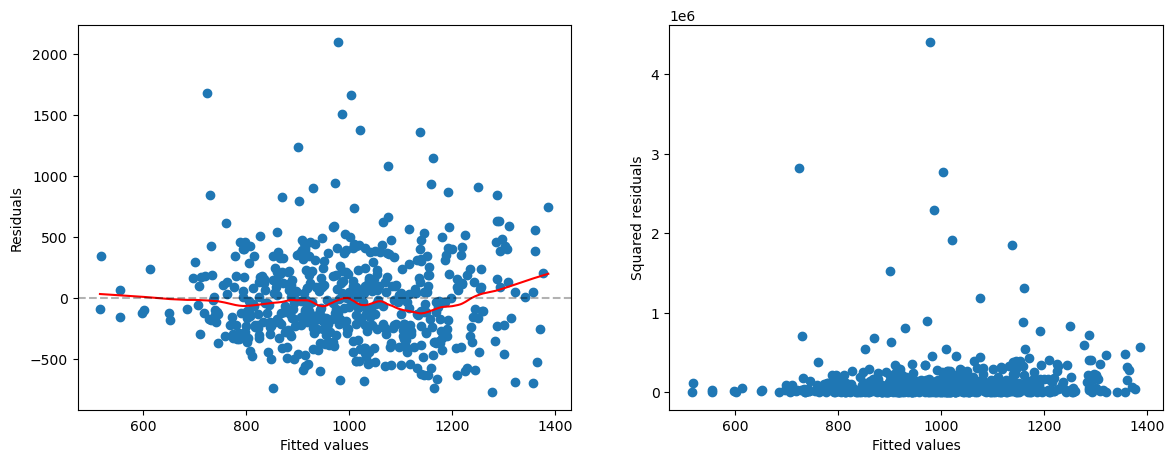

In [372]:
lowess = sm.nonparametric.lowess
#Residual and squared residual plots against fitted values
fig = plt.figure(figsize=(14,5))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)
ax1.scatter(newreg.fittedvalues,newreg.resid)
z1=lowess(newreg.resid,newreg.fittedvalues,frac=1./5)
ax1.plot(z1[:,0],z1[:,1],'red')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black',alpha=0.3,linestyle='--')
newreg2=newreg.resid**2
ax2.scatter(newreg.fittedvalues,newreg2)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Squared residuals')
plt.show()

In [373]:
newresid=newreg.resid
newfit=newreg.fittedvalues
newreg.mse_resid**0.5

376.8559328492954

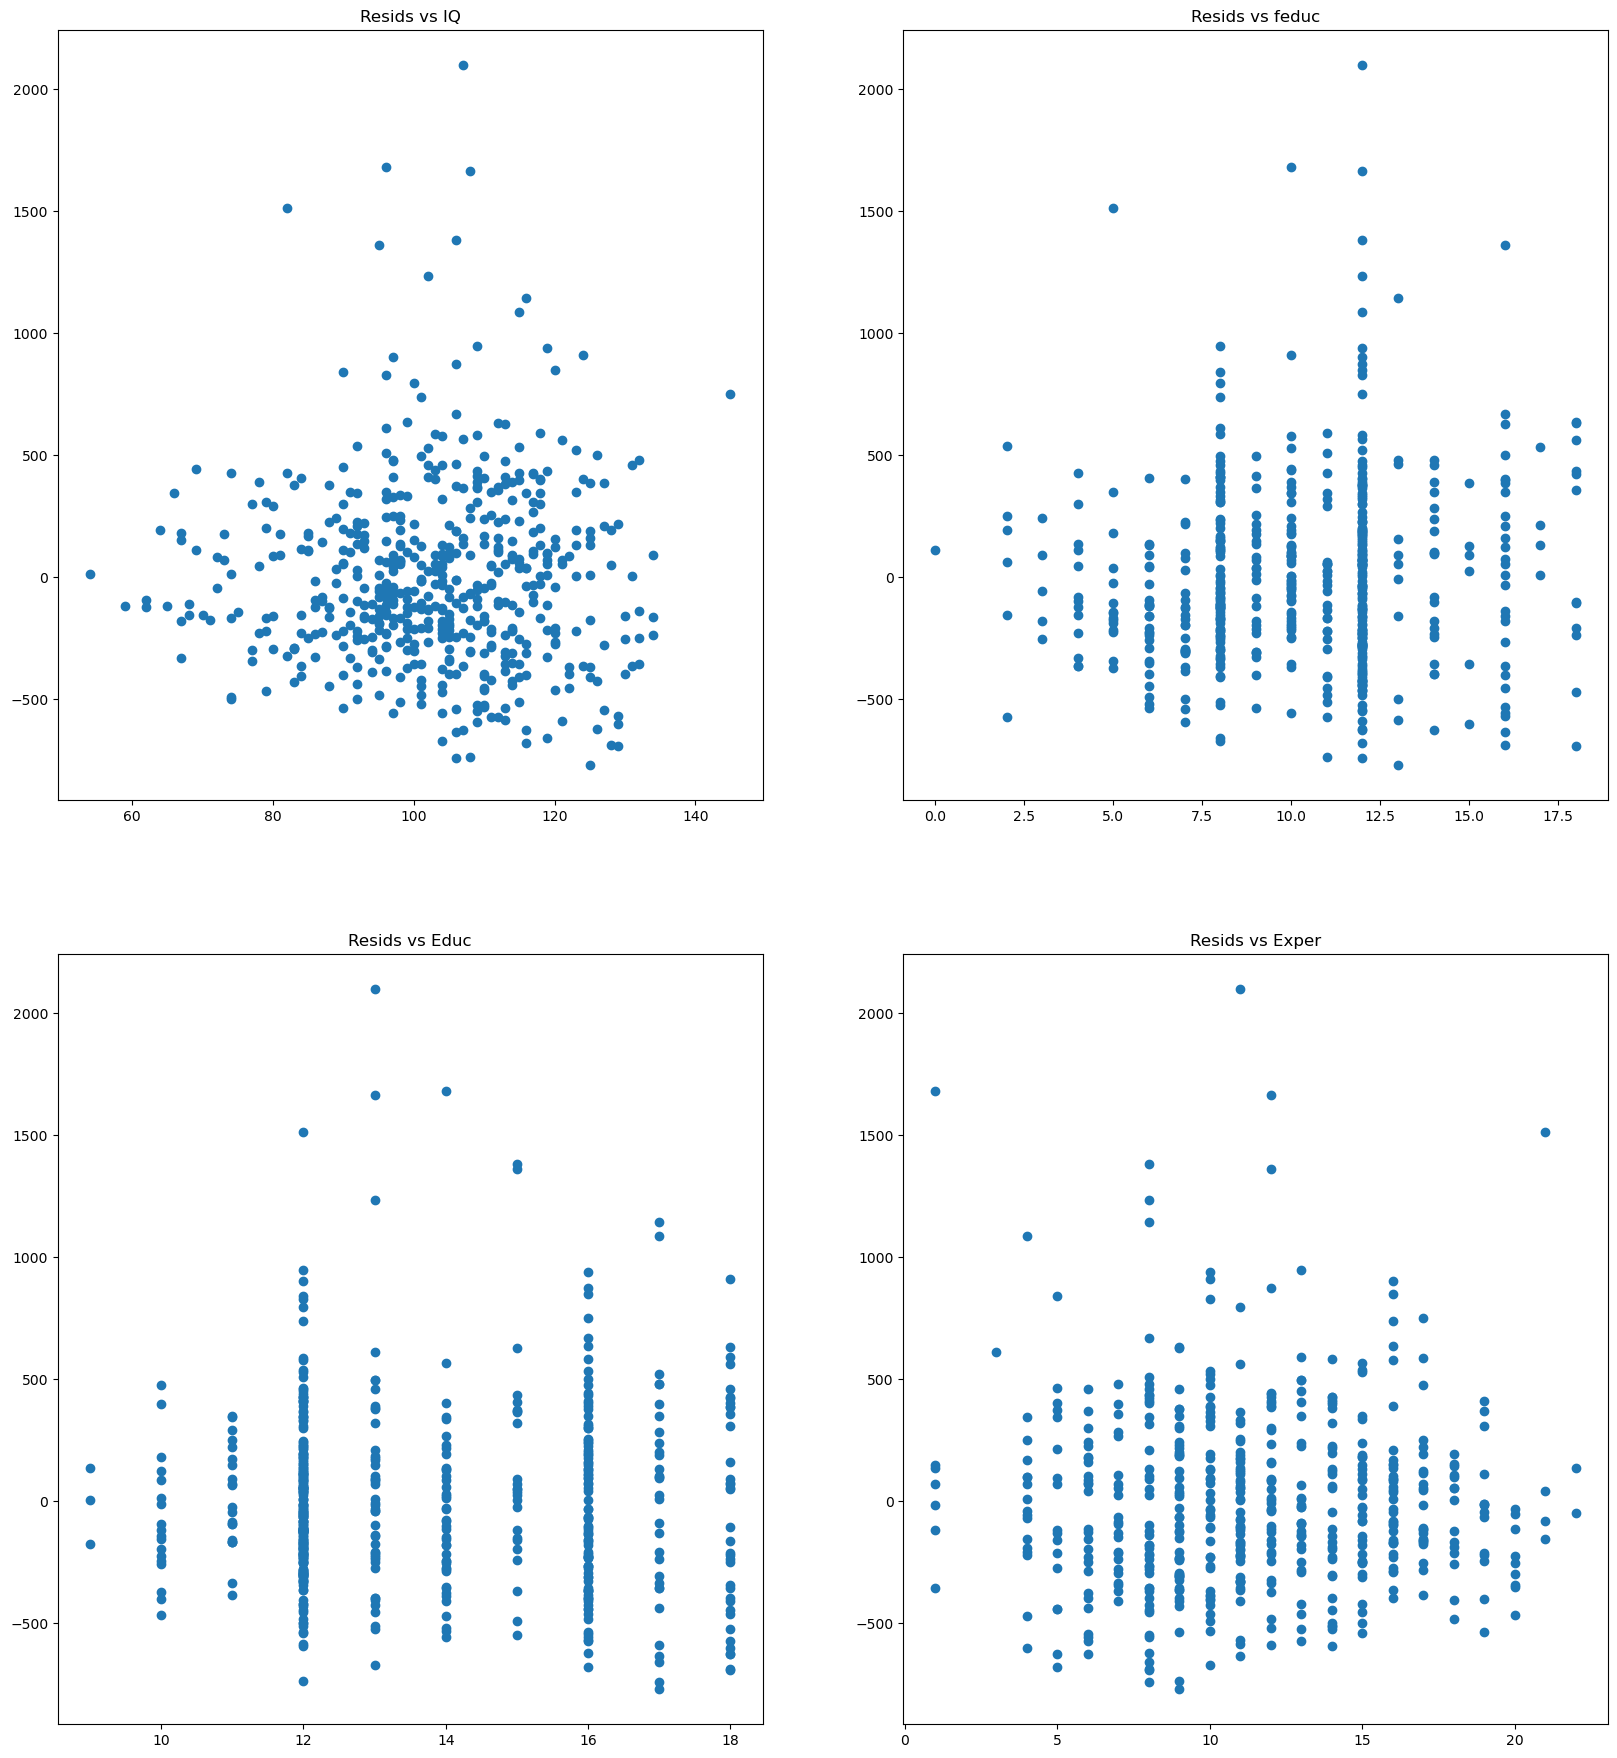

In [374]:
fig,ax=plt.subplots(2,2,figsize=(20,22))
ax[0,0].scatter(train['IQ'],newresid)
ax[0,0].set_title("Resids vs IQ")
ax[0,1].scatter(train['feduc'], newresid)
ax[0,1].set_title("Resids vs feduc")
ax[1,0].scatter(train['educ'],newresid)
ax[1,0].set_title("Resids vs Educ")
ax[1,1].scatter(train['exper'], newresid)
ax[1,1].set_title("Resids vs Exper")
plt.show()

In [375]:
#calculate VIFs for predictors
features=train[['educ','exper','IQ', 'feduc']]
features=sm.add_constant(features)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(1,features.shape[1]):
    vif_value=variance_inflation_factor(features.values,i)
    vif.append(vif_value)
    print(f"VIF for {features.columns[i]}: {vif_value:.3f}")
average_vif=sum(vif)/len(vif)
print(f"Average VIF: {average_vif:.3f}")

VIF for educ: 1.795
VIF for exper: 1.256
VIF for IQ: 1.476
VIF for feduc: 1.268
Average VIF: 1.449


The original reduced MLR was esimated as: $\hat{Wage} = -264.39 + 74.15 \times educ + 21.23 \times exper$. 95% confidence intervals for the two slopes are: $(58.04, 90.26)$ and $(12.74,29.72)$.

The new MLR is estimated as: $\hat{Wage} = -493.38 + 54.18 \times educ + 20.77 \times exper + 3.17 \times IQ + 16.73 \times meduc$. $95%$ confidence intervals for the four slopes are: $(34.99,73.37), (12.36,29.17), (0.52,5.81)$,and $(4.07,29.41)$.

The estimated effect of $educ$ in four-variable MLR has dropped to be lower than the 95% CI from the two-variable MLR. Clearly, $IQ$ and $meduc$ were was causing some OVB in this estimated effect in the two variable MLR.

The estimated effect of exper has become more positive, however the two 95% CIs have a large overlap and the difference in estimate here can probably be put down to simply estimation error, rather than OVB. 

For the added variables:

All variables are statistically significant, consistent with expectations.


The variance inflation can be measured by the $R^2$ in the regression of one regressor on the other. Both equal to $\frac{1}{1-r^2}$, where $r$ is the correlation between two variables, as calculated above, equal around 1. This is not a large number -- the usual threshold for the presence of a multicollinearity problem is 5.

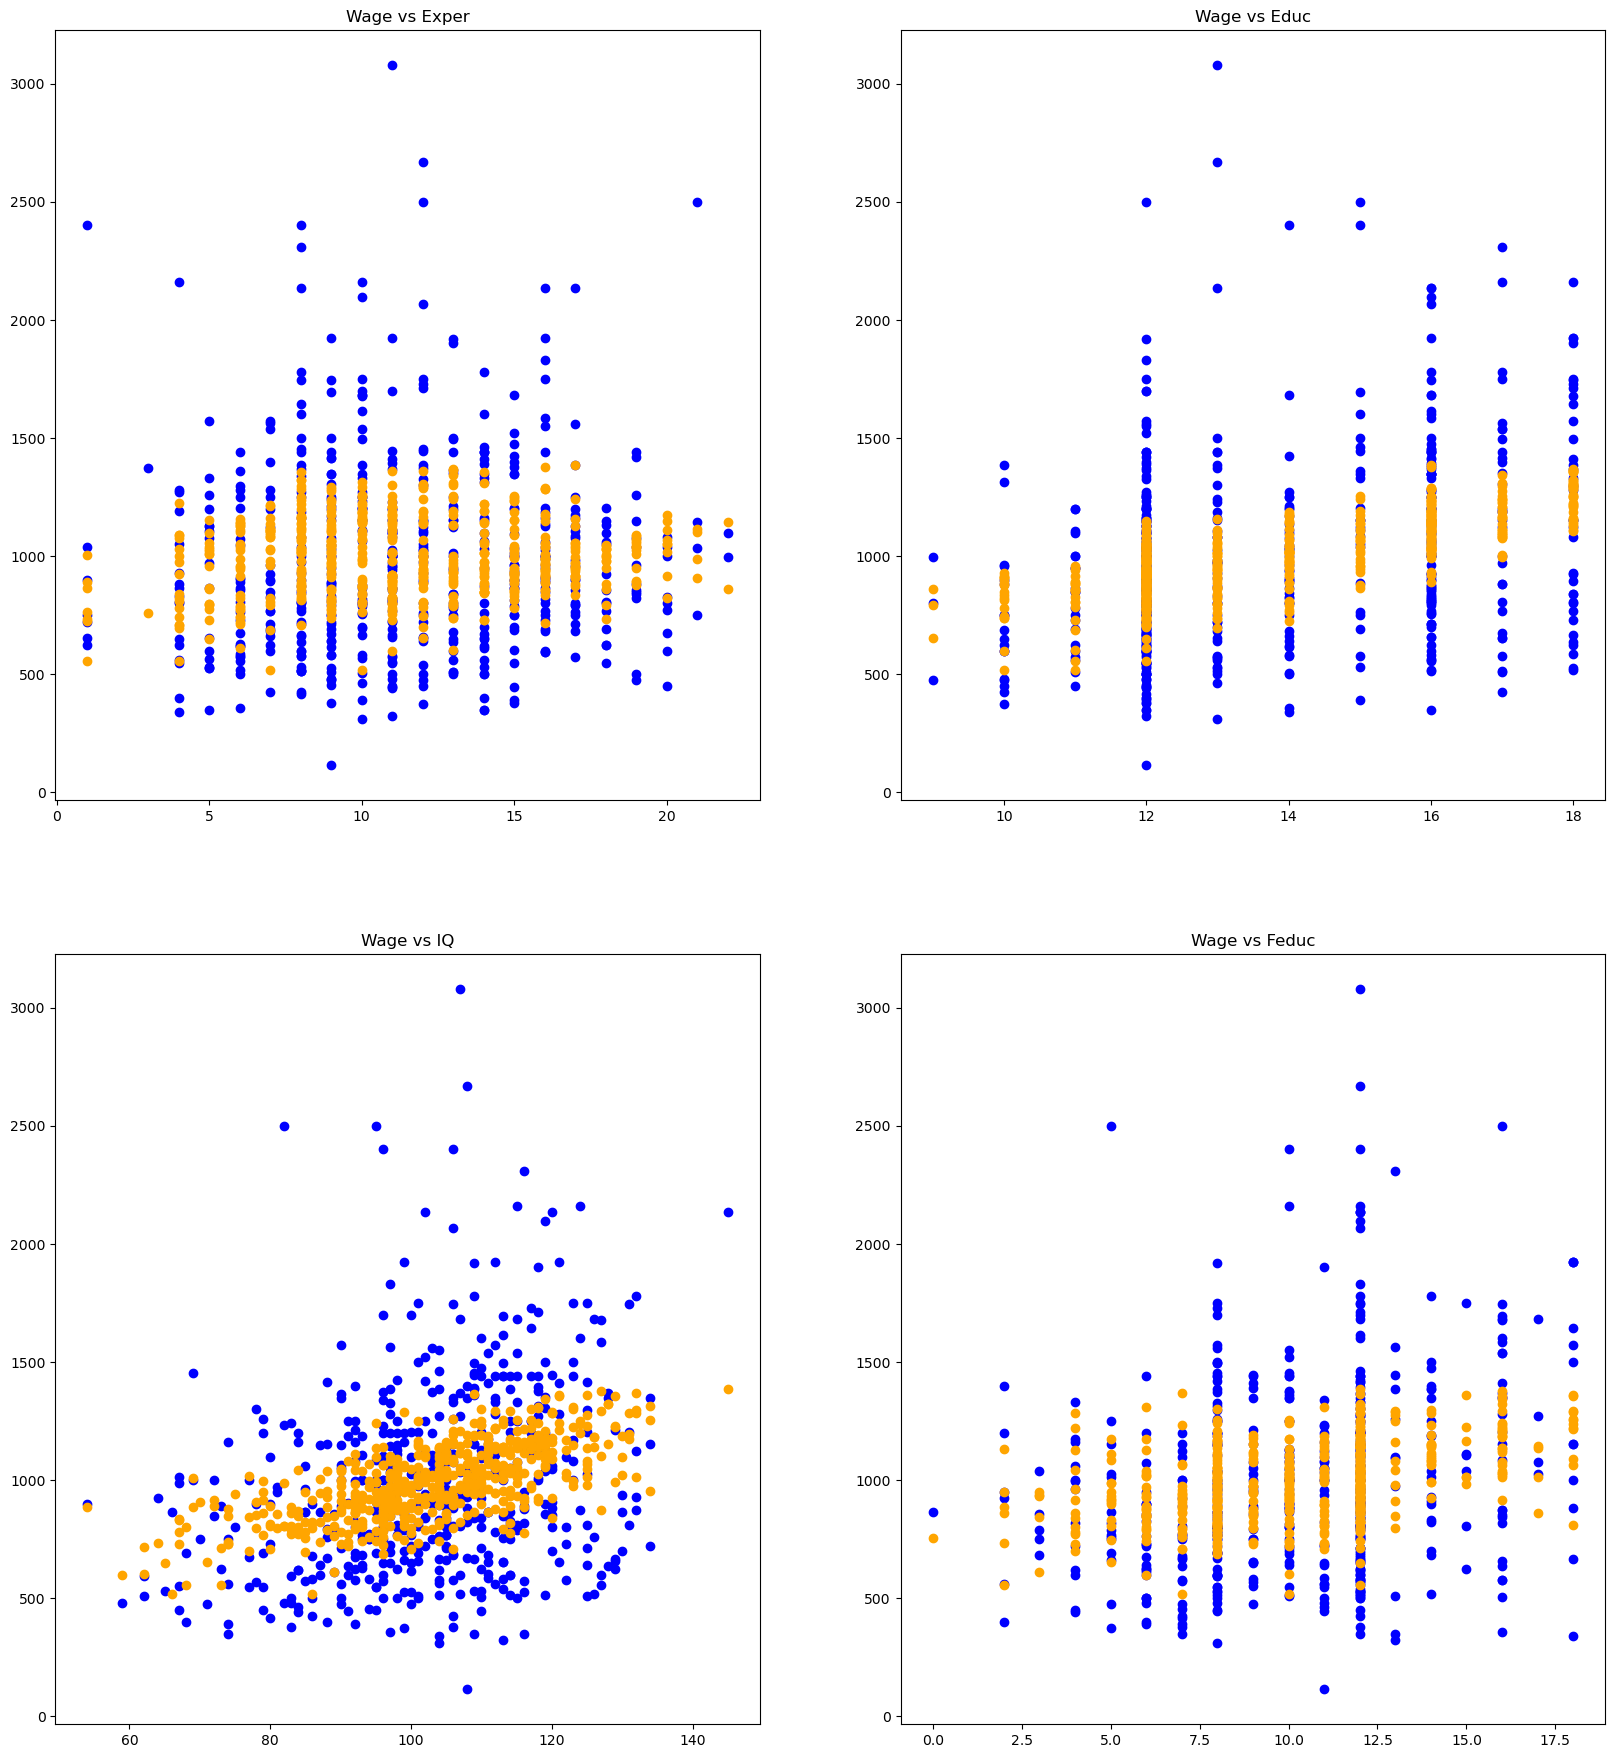

In [376]:
fig,ax=plt.subplots(2,2,figsize=(20,22))
ax[0,0].scatter(train['exper'], train['wage'], c='blue')
ax[0,0].scatter(train['exper'], newfit, c='orange')

ax[0,0].set_title('Wage vs Exper')
ax[0,1].scatter(train['educ'], train['wage'], c='blue')
ax[0,1].scatter(train['educ'], newfit, c='orange')

ax[0,1].set_title('Wage vs Educ')
ax[1,0].scatter(train['IQ'], train['wage'], c='blue')
ax[1,0].scatter(train['IQ'], newfit, c='orange')

ax[1,0].set_title('Wage vs IQ')
ax[1,1].scatter(train['feduc'], train['wage'], c='blue')
ax[1,1].scatter(train['feduc'], newfit, c='orange')

ax[1,1].set_title('Wage vs Feduc')

plt.show()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


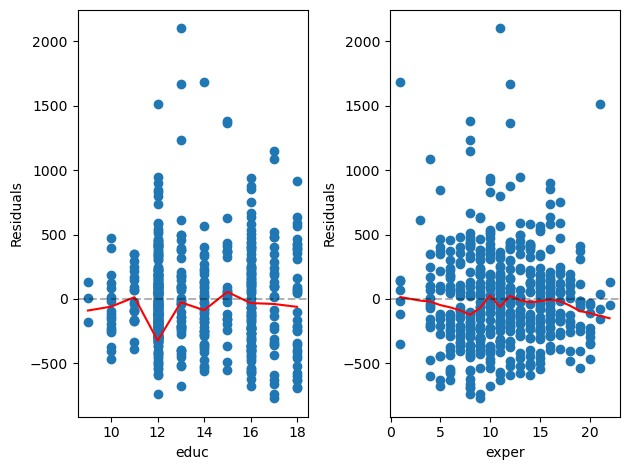

In [377]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

lowess = sm.nonparametric.lowess

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# First plot (educ vs residuals)
mask1 = (
    ~newreg.resid.isna() & 
    ~train['educ'].isna() & 
    np.isfinite(newreg.resid) & 
    np.isfinite(train['educ'])
)
ax1.scatter(train['educ'], newreg.resid)
z1 = lowess(newreg.resid[mask1], train['educ'][mask1], frac=1./5)
ax1.plot(z1[:, 0], z1[:, 1], 'red')
ax1.set_xlabel('educ')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black', alpha=0.3, linestyle='--')

# Second plot (exper vs residuals)
mask2 = (
    ~newreg.resid.isna() & 
    ~train['exper'].isna() & 
    np.isfinite(newreg.resid) & 
    np.isfinite(train['exper'])
)
ax2.scatter(train['exper'], newreg.resid)
z2 = lowess(newreg.resid[mask2], train['exper'][mask2], frac=1./5)
ax2.plot(z2[:, 0], z2[:, 1], 'red')
ax2.set_xlabel('exper')
ax2.set_ylabel('Residuals')
ax2.axhline(color='Black', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

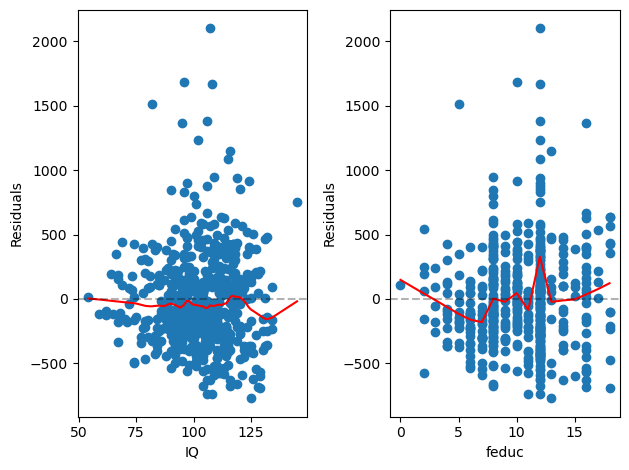

In [378]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

lowess = sm.nonparametric.lowess

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# First plot (educ vs residuals)
mask1 = (
    ~newreg.resid.isna() & 
    ~train['IQ'].isna() & 
    np.isfinite(newreg.resid) & 
    np.isfinite(train['IQ'])
)
ax1.scatter(train['IQ'], newreg.resid)
z1 = lowess(newreg.resid[mask1], train['IQ'][mask1], frac=1./5)
ax1.plot(z1[:, 0], z1[:, 1], 'red')
ax1.set_xlabel('IQ')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black', alpha=0.3, linestyle='--')

# Second plot (exper vs residuals)
mask2 = (
    ~newreg.resid.isna() & 
    ~train['feduc'].isna() & 
    np.isfinite(newreg.resid) & 
    np.isfinite(train['feduc'])
)
ax2.scatter(train['feduc'], newreg.resid)
z2 = lowess(newreg.resid[mask2], train['feduc'][mask2], frac=1./5)
ax2.plot(z2[:, 0], z2[:, 1], 'red')
ax2.set_xlabel('feduc')
ax2.set_ylabel('Residuals')
ax2.axhline(color='Black', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

The residuals vs fitted values plot shows that residuals are generally centered around zero, supporting the asusmption that $E(\epsilon|X) = 0$. The LOESS curve remains mostly flat, with no strong curvature, indicating that the linear functional form is reasonable approximation. However, residual spread appears to increase at higher fitted values, suggesting potential heteroskedasticity. The sqaured residual plot supports this, with some outliers at the upper end. Therefore, standard errors may benefit from heteroskedasticity-robust correction. 

The scatter plots of wage against each predictor, overlaid with fitted values (in orange), show that the linear model captures the main trends effectively. For education, predictions track the positive relationship with wage, though underprediction may occur for higher education levels. For experience, a similar trend is observed, but the wage gain appears to plateau. Including $exper^2$ in a later model may better capture this curvature. For IQ, the relationship is linear and strong, while $feduc$ shows a weaker but positive association.

Regarding the other MLR assumptions:

LSA 2 (Zero conditional mean): The residual plots support this assumption. Furthermore, including $IQ$ and $feduc$ helps reduce omitted variable bias from unobserved ability and family background that influence both education and wage. Their inclusion is supported by both theory and correlation structure.

LSA 3 (i.i.d. errors): The data is cross-sectional and lacks clustering or time structure, so this assumption is reasonably satisfied.

LSA 4 (Finite $4^{th}$ moments): Visual inspection of residual shows some outliers but no severe skewness or heavy tails. Predictors such as $IQ$ and $feduc$ are bounded and roughly symmetric. Thus, this assumption is likely to hold.

LSA 5 (No perfect multicollinearity): The correlation between $educ$ and $feduc$ is moderate ($0.42$), and between $IQ$ and $educ$ ($0.55$), which are acceptable. VIF values are not excessively high, so multicollinearity does not pose a major concern.

In conclusion, the reduced OVB model with $IQ$ and $feduc$ addresses key sources of bias and satisfies the main LSA conditions. While heteroskedasticity is present, it can be mitigated through robust standard errors. The model fits the data reasonably well and is appropriate for inference. 


The variable $married$ was selected for inclusion based on its meaningful improvement in model fit and strong statistical significance in the final model. Economically, marital status may influece wages through mechanisms such as household specialization. Including $married$ helps account for such life-stage and structural effects that are not captured by $educ$ and $exper$ alone. 

**1. Interaction effects**
We consider multiple interaction effects. 

IQ represents cognitive ability, which may enhance the capacity to benefit from formal education. Individuals with higher IQs are likely to process and apply knowledge more effectively, which leads to greater productivity hence higher wages. Therefore, an interaction term $IQ\times educ$ would be useul in capturing the possibility that the economic return to education is not uniform across cognitive ability levels. The term allows us to test whether the effect of IQ on education is significant in determining wages. 

Individuals with higher education benefits much more when combined with higher KWW. The interaction term $KWW\times educ$ assesses whether individuals with both high educational attainment and strong work-world knowledge experience amplified wage returns, as they can navigate job markets better and make the best of their qualifications. 

There might be a trade-off between $educ$ and $exper$ in shaping wages, that is individuals of higher education often access better career paths, where experience yields higher returns. For exmaple, one more year of experience may benefit somone with a bachelor degree far more than someone with a diploma degree. Hence, we consider the interaction term $exper\times educ$.

The economic return to education may vary by geographic context. Particularly, people living in urban areas have better access to more diverse and competitive educational environments, hence raising the impact of an additional year of education on wage. We include an interation term $urban\times educ$ to account for this.

While experience generally increases wages, sticking to one employer may limit wage growth, especially in competitive labor markets such as IT, as there are other employers who are willing to pay more. Hence, even highly experienced workers might see diminishing returns. To capture this dynamic, we include the interaction term $tenure\times exper$






**2. Data transformation**

As the histograms, $wage,hours$, and $tenure$ experience right-skewed distribution. Log transformation helps normalize the distribution and stabilize variance, making linear modeling assumptions more appropriate. On the other ahnd, $educ$ has a non-normal, multi-modal distribution, with peaks at common schooling milestones. Hence, log transformation can help reduce heteroskedasticity and smooth out jumps in marginal effects.

Moreover, the histogram shows a notable shift around 15 years of education, typically the transition from highschool to higher education. This knot allows the model to flexibly capture different wage returns before and after this educational threshold. Nonetheless, the age distribution suggests a change in density around age 35, which often marks a shift in career stage. A spline at this point allows the model to account for potentially different wage growth patterns before and after this age

**3. Forward & backward selection**

After incorporating all relevant transformed variables and interaction terms, we performed forward and backward stepwise selection using $log(wage)$ as the dependent variable. The final model, presented in the appendix, reflects a parsimonious specification based on model fit criteria. However, we excluded the variables $black$ and $brthord$ from the final model testing. Although initially considered, both variables showed marginal statistical contribution. Qualitatively, race may introduce interpretive complexity and is less actionable from a policy perspective, while birth order likely influences outcomes indirectly through other included variables such as education or cognitive ability. To maintain model simplicity and interpretability, we opted to exclude these variables from the final specification.

Model 1. Base model, $urban$ from forward selection

$lwage = 5.1635 + 0.0507\times educ + 0.0236\times exper + 0.0036\times IQ + 0.0169\times meduc + 0.1908\times urban$

This model serves as the base specification, incorporating key human capital variables — education, experience, IQ, and mother’s education — along with the addition of urban, selected through forward selection. The model achieves an adjusted R² of $0.209$ and a standard error of regression (SER) of $373.63$, consistent with early-stage models. All variables are statistically significant at the 1% level, indicating strong individual contributions to explaining variation in $lwage$$. 

The positive and significant coefficient on $urban$ suggests that individuals residing in urban areas earn higher wages, likely due to better job opportunities and higher labor market competition. This model establishes a solid foundation for further exploration of interaction effects and non-linear transformations.





In [379]:
xi_age =train['age'].median()
train['Step_age']=(train['age']>xi_age)*(train['age']-xi_age)
test['Step_age']=(test['age']>xi_age)*(test['age']-xi_age)
train['lhours']=np.log(train['hours'])
test['lhours']=np.log(test['hours'])
train['ltenure']=np.log(train['tenure']+1)
test['ltenure']=np.log(test['tenure']+1)
train['lbrth']=np.log(train['brthord']+1)
test['lbrth']=np.log(test['brthord']+1)
model1 = smf.ols(formula='lwage ~ educ + exper + IQ + meduc + urban ',data=train)
reg1=model1.fit()
reg1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     28.94
Date:                Thu, 29 May 2025   Prob (F-statistic):           5.83e-26
Time:                        19:55:27   Log-Likelihood:                -214.76
No. Observations:                 531   AIC:                             441.5
Df Residuals:                     525   BIC:                             467.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1635      0.152     33.968      0.000       4.865       5.462
educ           0.0507      0.009      5.349      0.000       0.032       0.069
exper          0.0236      0.004      5.708      0.000       0.015       0.032
IQ             0.0036      0.001      2.769      0.006       0.001       0.006
meduc          0.0169      0.006      2.708      0.007       0.005       0.029
urban          0.1908      0.035      5.383      0.000       0.121       0.260
==============================================================================
Omnibus:                       33.480   Durbin-Watson:                   1.738
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               83.193
Skew:                          -0.300   Prob(JB):                     8.61e-19
Kurtosis:                       4.844   Cond. No.                     1.02e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.02e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [420]:
resid1=reg1.resid
fit1=reg1.fittedvalues
reg1.mse_resid ** 0.5
original_scale_predictions_1 = np.exp(reg1.fittedvalues)
original_residuals_1 = train['wage'] - original_scale_predictions_1
n = len (train[ 'wage' ])
p = reg1.df_model
ser_original_scale_1 = np.sqrt(np.sum(original_residuals_1 ** 2) / (n - p - 1))
print(ser_original_scale_1)

373.63060740258527


Model 2. Base model, urban, married


$lwage = 5.0315+0.0517\times educ +0.0221 \times exper + 0.0035 \times IQ + 0.0162 \times meduc + 0.196\times urban + 0.1665\times married$.

Adjusted R-squared is $0.222$, SER = $370.58$

 The inclusion of $married$ improves the model’s adjusted R² to $0.222$, with an increase in overall model fit. All variables remain statistically significant at conventional levels, including $married$, which shows a positive and significant association with $lwage$. This suggests that marital status may be linked to greater wage stability or labor market attachment, reinforcing its relevance in wage determination.

In [422]:
model2 = smf.ols(formula='lwage ~ educ + exper + IQ + meduc + urban + married',data=train)
reg2=model2.fit()
reg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     26.14
Date:                Thu, 29 May 2025   Prob (F-statistic):           3.06e-27
Time:                        21:16:05   Log-Likelihood:                -209.88
No. Observations:                 531   AIC:                             433.8
Df Residuals:                     524   BIC:                             463.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0315      0.157     32.129      0.000       4.724       5.339
educ           0.0517      0.009      5.495      0.000       0.033       0.070
exper          0.0221      0.004      5.358      0.000       0.014       0.030
IQ             0.0035      0.001      2.714      0.007       0.001       0.006
meduc          0.0162      0.006      2.607      0.009       0.004       0.028
urban          0.1960      0.035      5.567      0.000       0.127       0.265
married        0.1665      0.053      3.117      0.002       0.062       0.271
==============================================================================
Omnibus:                       35.750   Durbin-Watson:                   1.764
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               94.351
Skew:                          -0.305   Prob(JB):                     3.25e-21
Kurtosis:                       4.973   Cond. No.                     1.06e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.06e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [421]:
resid2=reg2.resid
fit2=reg2.fittedvalues
reg2.mse_resid ** 0.5
original_scale_predictions_2 = np.exp(reg2.fittedvalues)
original_residuals_2 = train['wage'] - original_scale_predictions_2
n = len (train[ 'wage' ])
p = reg2.df_model
ser_original_scale_2 = np.sqrt(np.sum(original_residuals_2 ** 2) / (n - p - 1))
print(ser_original_scale_2)

370.5832949631515


Model 3. Base model, log(tenure), urban, married

$lwage = 5.0215+0.0476\times educ +0.0184 \times exper + 0.0034 \times IQ + 0.0162 \times meduc + 0.0683\times ltenure +0.1975\times urban + 0.1562\times married$

Adjusted R-squared is $0.235$, SER = $370.43$

The inclusion of $ltenure$ improves the model’s adjusted R² to $0.235$, with a corresponding SER of $370.43$, indicating a better fit than previous models. All variables remain statistically significant at the $5\%$ level, including $ltenure$, which shows a positive and meaningful association with $lwage$. This supports the idea that longer tenure, especially when modeled logarithmically, contributes to higher earnings, likely reflecting firm-specific human capital accumulation and job stability.


In [423]:
model3 = smf.ols(formula='lwage ~ educ + exper + IQ + meduc + ltenure + urban + married',data=train)
reg3=model3.fit()
reg3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     24.22
Date:                Thu, 29 May 2025   Prob (F-statistic):           1.34e-28
Time:                        21:17:38   Log-Likelihood:                -204.85
No. Observations:                 531   AIC:                             425.7
Df Residuals:                     523   BIC:                             459.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0215      0.155     32.334      0.000       4.716       5.327
educ           0.0476      0.009      5.061      0.000       0.029       0.066
exper          0.0184      0.004      4.299      0.000       0.010       0.027
IQ             0.0034      0.001      2.667      0.008       0.001       0.006
meduc          0.0162      0.006      2.641      0.009       0.004       0.028
ltenure        0.0683      0.022      3.163      0.002       0.026       0.111
urban          0.1975      0.035      5.659      0.000       0.129       0.266
married        0.1562      0.053      2.943      0.003       0.052       0.260
==============================================================================
Omnibus:                       33.730   Durbin-Watson:                   1.756
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              109.453
Skew:                          -0.172   Prob(JB):                     1.71e-24
Kurtosis:                       5.197   Cond. No.                     1.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [425]:
resid3=reg3.resid
fit3=reg3.fittedvalues
reg3.mse_resid ** 0.5
original_scale_predictions_3 = np.exp(reg3.fittedvalues)
original_residuals_3 = train['wage'] - original_scale_predictions_3
n = len (train[ 'wage' ])
p = reg3.df_model
ser_original_scale_3 = np.sqrt(np.sum(original_residuals_3 ** 2) / (n - p - 1))
print(ser_original_scale_3)

370.42367003673303


Model 4. Base model, log(tenure), forward selection $urban, married$, interaction term $exper\times educ$

$lwage = 5.6857-0.0009\times educ -0.042 \times exper + 0.0032 \times IQ + 0.0161 \times meduc + 0.0743\times ltenure + 0.1962\times urban + 0.1577\times married + 0.0046\times exper\times educ$

Adjusted R-squared is $0.242$, SER = $368.41$

 The model achieves an adjusted R² of $0.242$ and a SER of $368.41$, showing a modest improvement in fit over previous models. The interaction term allows for more flexible modeling of wage dynamics across different education-experience profiles.
 
However, caution is warranted. The main effects of both $educ$ and $exper$ become statistically insignificant, and their coefficients change signs, which may indicate multicollinearity or overfitting due to the inclusion of the interaction term. This can make interpretation less straightforward and may reduce the model’s generalizability. Therefore, while the interaction adds nuance, its inclusion should be carefully considered in light of these trade-offs.

In [385]:
train['exper_educ']=train['exper']*train['educ']
model4= smf.ols(formula='lwage ~ educ + exper + IQ + meduc + ltenure + urban + married +exper:educ',data=train)
reg4=model4.fit()
reg4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     22.10
Date:                Thu, 29 May 2025   Prob (F-statistic):           4.38e-29
Time:                        19:55:27   Log-Likelihood:                -201.94
No. Observations:                 531   AIC:                             421.9
Df Residuals:                     522   BIC:                             460.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6857      0.317     17.914      0.000       5.062       6.309
educ          -0.0009      0.022     -0.040      0.968      -0.045       0.043
exper         -0.0420      0.026     -1.644      0.101      -0.092       0.008
IQ             0.0032      0.001      2.527      0.012       0.001       0.006
meduc          0.0161      0.006      2.633      0.009       0.004       0.028
ltenure        0.0743      0.022      3.432      0.001       0.032       0.117
urban          0.1962      0.035      5.647      0.000       0.128       0.264
married        0.1577      0.053      2.984      0.003       0.054       0.261
exper:educ     0.0046      0.002      2.396      0.017       0.001       0.008
==============================================================================
Omnibus:                       35.136   Durbin-Watson:                   1.768
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              123.463
Skew:                          -0.144   Prob(JB):                     1.55e-27
Kurtosis:                       5.345   Cond. No.                     3.92e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.92e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [426]:
resid4=reg4.resid
fit4=reg4.fittedvalues
reg4.mse_resid ** 0.5
original_scale_predictions_4 = np.exp(reg4.fittedvalues)
original_residuals_4 = train['wage'] - original_scale_predictions_4
n = len (train[ 'wage' ])
p = reg4.df_model
ser_original_scale_4 = np.sqrt(np.sum(original_residuals_4 ** 2) / (n - p - 1))
print(ser_original_scale_4)

368.4111340108613


Model 5. Base model, $log(tenure)$, forward selection $urban, married, south$

$lwage = 5.0851+0.0484\times educ +0.0179 \times exper + 0.0031 \times IQ + 0.015 \times meduc + 0.0654\times ltenure - 0.0607\times south +0.1583\times married+0.1924\times urban$.

Adjusted R-squared is $0.238$, SER = $370.58$

The adjusted R² is $0.238$, and the SER is $370.58$, which is slightly higher than that of Model 3 (SER = $370.43$). The coefficient on $south$ is negative and statistically significant, suggesting that, holding other factors constant, individuals in the southern region tend to earn lower wages — a finding consistent with regional wage disparities observed in labor economics.

However, the inclusion of south does not substantially improve model fit compared to Model 3. Given the minimal gain in explanatory power and the slight increase in SER, the practical value of adding this variable may be limited unless regional effects are of specific interest in the analysis.




In [387]:
model5= smf.ols(formula='lwage ~ educ + exper + IQ + meduc + ltenure + south+married+urban',data=train)
reg5=model5.fit()
reg5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     21.68
Date:                Thu, 29 May 2025   Prob (F-statistic):           1.47e-28
Time:                        19:55:27   Log-Likelihood:                -203.22
No. Observations:                 531   AIC:                             424.4
Df Residuals:                     522   BIC:                             462.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0851      0.159     31.984      0.000       4.773       5.397
educ           0.0484      0.009      5.153      0.000       0.030       0.067
exper          0.0179      0.004      4.191      0.000       0.010       0.026
IQ             0.0031      0.001      2.436      0.015       0.001       0.006
meduc          0.0150      0.006      2.432      0.015       0.003       0.027
ltenure        0.0654      0.022      3.025      0.003       0.023       0.108
south         -0.0607      0.034     -1.792      0.074      -0.127       0.006
married        0.1583      0.053      2.988      0.003       0.054       0.262
urban          0.1924      0.035      5.504      0.000       0.124       0.261
==============================================================================
Omnibus:                       34.304   Durbin-Watson:                   1.737
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              117.137
Skew:                          -0.148   Prob(JB):                     3.67e-26
Kurtosis:                       5.282   Cond. No.                     1.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [388]:
resid5=reg5.resid
fit5=reg5.fittedvalues
reg5.mse_resid ** 0.5
original_scale_predictions_5 = np.exp(reg5.fittedvalues)
original_residuals_5 = train['wage'] - original_scale_predictions_5
n = len (train[ 'wage' ])
p = reg5.df_model
ser_original_scale_5 = np.sqrt(np.sum(original_residuals_5 ** 2) / (n - p - 1))
print(ser_original_scale_5)

370.5795662228379


Model 6. Base model, $log(tenure)$, forward selection $married, urban, log(hours)$

$lwage = 5.6576+0.0476\times educ +0.0177 \times exper +0.0035 \times IQ + 0.0164 \times meduc + 0.0676\times ltenure -0.1693\times lhours+0.163\times married+0.1966\times urban$.

Adjusted R-squared is $0.237$, SER = $370.64$

 Although $lhours$ is not statistically significant ($p = 0.103$), it is retained due to its theoretical relevance—working hours are an important determinant of wage variation in labor economics. The adjusted R-squared is $0.237$ and SER increases slightly to $370.64$, indicating a marginal decline in model fit compared to Model 4. However, the inclusion of $lhours$ allows for a more comprehensive specification that captures potential labor supply effects.


In [427]:
train['hourssqrt'] = np.sqrt(train['hours'])
model6= smf.ols(formula='lwage ~ educ + exper + IQ + meduc + ltenure + lhours+married +urban',data=train)
reg6=model6.fit()
reg6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     21.59
Date:                Thu, 29 May 2025   Prob (F-statistic):           1.91e-28
Time:                        21:25:41   Log-Likelihood:                -203.49
No. Observations:                 531   AIC:                             425.0
Df Residuals:                     522   BIC:                             463.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6576      0.419     13.502      0.000       4.834       6.481
educ           0.0476      0.009      5.068      0.000       0.029       0.066
exper          0.0177      0.004      4.119      0.000       0.009       0.026
IQ             0.0035      0.001      2.709      0.007       0.001       0.006
meduc          0.0164      0.006      2.669      0.008       0.004       0.028
ltenure        0.0676      0.022      3.137      0.002       0.025       0.110
lhours        -0.1693      0.104     -1.634      0.103      -0.373       0.034
married        0.1630      0.053      3.068      0.002       0.059       0.267
urban          0.1966      0.035      5.642      0.000       0.128       0.265
==============================================================================
Omnibus:                       32.525   Durbin-Watson:                   1.759
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              107.665
Skew:                          -0.132   Prob(JB):                     4.18e-24
Kurtosis:                       5.190   Cond. No.                     2.94e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.94e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [429]:
resid6=reg6.resid
fit6=reg6.fittedvalues
reg6.mse_resid ** 0.5
original_scale_predictions_6 = np.exp(reg6.fittedvalues)
original_residuals_6 = train['wage'] - original_scale_predictions_6
n = len (train[ 'wage' ])
p = reg6.df_model
ser_original_scale_6 = np.sqrt(np.sum(original_residuals_6 ** 2) / (n - p - 1))
print(ser_original_scale_6)

370.64097418737435


Model 7. Base model, $log(tenure),log(hours)$, forward selection $ urban, married, KWW$

$lwage = 5.7534+0.0397\times educ +0.0149 \times exper + 0.0028 \times IQ + 0.0139 \times meduc + 0.06\times ltenure - 0.1912\times lhours + 0.1906\times urban + 0.00679\times KWW +0.1575\times married$.

Adjusted R-squared is $0.247$, SER = $367.2$

The adjusted R-squared increases to $0.247$, and SER improves to $367.2$, indicating a better fit. All variables remain statistically significant at the $5\%$ level except $lhours$.

While $KWW$ is statistically significant, it may overlap conceptually with $IQ$ and introduce multicollinearity. Additionally, if KWW is influenced by prior work exposure, it could be endogenous, potentially biasing the estimates.



In [430]:
model7= smf.ols(formula='lwage ~ educ + exper + IQ + meduc + ltenure + lhours+urban+KWW+married ',data=train)
reg7=model7.fit()
reg7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     20.32
Date:                Thu, 29 May 2025   Prob (F-statistic):           2.18e-29
Time:                        21:37:05   Log-Likelihood:                -199.53
No. Observations:                 531   AIC:                             419.1
Df Residuals:                     521   BIC:                             461.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.7534      0.418     13.774      0.000       4.933       6.574
educ           0.0397      0.010      4.072      0.000       0.021       0.059
exper          0.0149      0.004      3.417      0.001       0.006       0.024
IQ             0.0028      0.001      2.137      0.033       0.000       0.005
meduc          0.0139      0.006      2.253      0.025       0.002       0.026
ltenure        0.0600      0.022      2.778      0.006       0.018       0.102
lhours        -0.1912      0.103     -1.852      0.065      -0.394       0.012
urban          0.1906      0.035      5.493      0.000       0.122       0.259
KWW            0.0069      0.002      2.801      0.005       0.002       0.012
married        0.1575      0.053      2.980      0.003       0.054       0.261
==============================================================================
Omnibus:                       39.657   Durbin-Watson:                   1.757
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.394
Skew:                          -0.189   Prob(JB):                     5.98e-33
Kurtosis:                       5.562   Cond. No.                     3.12e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.12e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [431]:
resid7=reg7.resid
fit7=reg7.fittedvalues
reg7.mse_resid ** 0.5
original_scale_predictions_7 = np.exp(reg7.fittedvalues)
original_residuals_7 = train['wage'] - original_scale_predictions_7
n = len (train[ 'wage' ])
p = reg7.df_model
ser_original_scale_7 = np.sqrt(np.sum(original_residuals_7 ** 2) / (n - p - 1))
print(ser_original_scale_7)

367.19965521501393


Model 8. Base model, $log(tenure)$, forward selection $south, urban, married$, interaction term $IQ \times educ$

$lwage = 5.2159+0/0803\times educ +0.0179 \times exper +0.0075 \times IQ + 0.0162 \times meduc + 0.0679\times ltenure -0.1656\times lhours +0.1607\times married + 0.1954\times urban -0.0003\times IQ\times educ$

Adjusted R-squared is $0.236$, SER = $370.99$

 The adjusted R-squared decreases to $0.236$, and SER increases to $370.99$, indicating a slight decline in model fit compared to Model 6.


In [393]:
model8= smf.ols(formula='lwage ~ educ + exper + IQ + meduc + ltenure +lhours+married+urban+IQ:educ ',data=train)
reg8=model8.fit()
reg8.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     19.21
Date:                Thu, 29 May 2025   Prob (F-statistic):           7.82e-28
Time:                        19:55:27   Log-Likelihood:                -203.32
No. Observations:                 531   AIC:                             426.6
Df Residuals:                     521   BIC:                             469.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2159      0.868      6.011      0.000       3.511       6.921
educ           0.0803      0.057      1.410      0.159      -0.032       0.192
exper          0.0179      0.004      4.156      0.000       0.009       0.026
IQ             0.0075      0.007      1.065      0.287      -0.006       0.021
meduc          0.0162      0.006      2.631      0.009       0.004       0.028
ltenure        0.0679      0.022      3.147      0.002       0.026       0.110
lhours        -0.1656      0.104     -1.594      0.111      -0.370       0.038
married        0.1607      0.053      3.014      0.003       0.056       0.266
urban          0.1954      0.035      5.593      0.000       0.127       0.264
IQ:educ       -0.0003      0.001     -0.581      0.561      -0.001       0.001
==============================================================================
Omnibus:                       32.495   Durbin-Watson:                   1.763
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              107.403
Skew:                          -0.132   Prob(JB):                     4.76e-24
Kurtosis:                       5.187   Cond. No.                     8.33e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.33e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [433]:
resid8=reg8.resid
fit8=reg8.fittedvalues
reg8.mse_resid ** 0.5
original_scale_predictions_8 = np.exp(reg8.fittedvalues)
original_residuals_8 = train['wage'] - original_scale_predictions_8
n = len (train[ 'wage' ])
p = reg8.df_model
ser_original_scale_8 = np.sqrt(np.sum(original_residuals_8 ** 2) / (n - p - 1))
print(ser_original_scale_8)

370.99175587058966


Model 9. Base model, $log(tenure)$, forward selection $south, married$, spline $age, urban$

$lwage = 5.7238+0.0449\times educ +0.0147 \times exper + 0.0036 \times IQ + 0.0157 \times meduc + 0.0678\times ltenure - 0.1746\times hours  +0.1588\times married+0.01993\times urban+ 0.0259\times spline\_age\_35$.

Adjusted R-squared is $0.239$, SER = $370.23$

 The adjusted R-squared increases slightly to $0.239$, and SER improves to $370.23$. However, the spline term is not statistically significant ($p = 0.136$), and thus is not retained. Instead, the model will continue using age as a linear predictor in subsequent specifications.

In [434]:
train['spline_age_35'] = np.maximum(0, train['age'] - 35)
model9= smf.ols(formula='lwage ~ educ + exper + IQ + meduc + ltenure + lhours+married+urban+spline_age_35',data=train)
reg9=model9.fit()
reg9.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     19.49
Date:                Thu, 29 May 2025   Prob (F-statistic):           3.16e-28
Time:                        21:44:01   Log-Likelihood:                -202.36
No. Observations:                 531   AIC:                             424.7
Df Residuals:                     521   BIC:                             467.5
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.7238      0.421     13.600      0.000       4.897       6.551
educ              0.0449      0.010      4.701      0.000       0.026       0.064
exper             0.0147      0.005      3.117      0.002       0.005       0.024
IQ                0.0036      0.001      2.840      0.005       0.001       0.006
meduc             0.0157      0.006      2.555      0.011       0.004       0.028
ltenure           0.0678      0.022      3.148      0.002       0.025       0.110
lhours           -0.1746      0.104     -1.686      0.092      -0.378       0.029
married           0.1588      0.053      2.988      0.003       0.054       0.263
urban             0.1993      0.035      5.717      0.000       0.131       0.268
spline_age_35     0.0259      0.017      1.493      0.136      -0.008       0.060
==============================================================================
Omnibus:                       31.879   Durbin-Watson:                   1.754
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              103.699
Skew:                          -0.131   Prob(JB):                     3.03e-23
Kurtosis:                       5.149   Cond. No.                     2.96e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.96e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [435]:
resid9=reg9.resid
fit9=reg9.fittedvalues
reg9.mse_resid ** 0.5
original_scale_predictions_9 = np.exp(reg9.fittedvalues)
original_residuals_9 = train['wage'] - original_scale_predictions_9
n = len (train[ 'wage' ])
p = reg9.df_model
ser_original_scale_9 = np.sqrt(np.sum(original_residuals_9 ** 2) / (n - p - 1))
print(ser_original_scale_9)

370.23417089254707


Model 10. Base model with $log(tenure),log(hours)$, forward selection $,married, age, urban$, and interaction term $age\times educ$.

$lwage = 7.6751 -0.122\times educ + 0.0135\times exper + 0.0038\times IQ + 0.0158\times meduc + 0.0649\times ltenure - 0.1923\times lhours +0.1617\times married +0.2067\times urban + 0.0544\times age + 0.0049\times age\times educ$

Adjusted R-squared = $0.247$, SER = $367.77$

The adjusted R-squared increases to $0.247$, and SER improves to $367.77$, indicating a better fit than the previous model. The interaction term is statistically significant at the $5\%$ level ($p = 0.039$), suggesting a potential moderating effect of age on the return to education. This interaction will be considered further in evaluating whether it should be included in the optimal model specification.

In [437]:

model10= smf.ols(formula='lwage ~ educ + exper + IQ + meduc + ltenure + married+urban+lhours+age+age:educ',data=train)
reg10=model10.fit()
reg10.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     18.35
Date:                Thu, 29 May 2025   Prob (F-statistic):           7.05e-29
Time:                        21:57:44   Log-Likelihood:                -199.13
No. Observations:                 531   AIC:                             420.3
Df Residuals:                     520   BIC:                             467.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.6751      1.187      6.467      0.000       5.344      10.006
educ          -0.1220      0.079     -1.537      0.125      -0.278       0.034
exper          0.0135      0.005      2.597      0.010       0.003       0.024
IQ             0.0038      0.001      2.928      0.004       0.001       0.006
meduc          0.0158      0.006      2.582      0.010       0.004       0.028
ltenure        0.0649      0.021      3.023      0.003       0.023       0.107
married        0.1617      0.053      3.062      0.002       0.058       0.265
urban          0.2067      0.035      5.934      0.000       0.138       0.275
lhours        -0.1923      0.103     -1.862      0.063      -0.395       0.011
age           -0.0544      0.033     -1.641      0.101      -0.119       0.011
age:educ       0.0049      0.002      2.065      0.039       0.000       0.010
==============================================================================
Omnibus:                       33.463   Durbin-Watson:                   1.770
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              114.249
Skew:                          -0.128   Prob(JB):                     1.55e-25
Kurtosis:                       5.258   Cond. No.                     3.66e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.66e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [436]:
resid10=reg10.resid
fit10=reg10.fittedvalues
reg10.mse_resid ** 0.5
original_scale_predictions_10 = np.exp(reg10.fittedvalues)
original_residuals_10 = train['wage'] - original_scale_predictions_10
n = len (train[ 'wage' ])
p = reg10.df_model
ser_original_scale_10 = np.sqrt(np.sum(original_residuals_10 ** 2) / (n - p - 1))
print(ser_original_scale_10)

367.76953102355316


Model 10. Base model with $log(tenure)$, forward selection $,married, urban$

$lwage = 7.6751 -0.122\times educ + 0.0135\times exper + 0.0038\times IQ + 0.0158\times meduc + 0.0649\times ltenure - 0.1923\times lhours +0.1617\times married +0.2067\times urban + 0.0544\times age + 0.0049\times age\times educ$

Adjusted R-squared = $0.247$, SER = $367.77$

The adjusted R-squared increases to $0.247$, and SER improves to $367.77$, indicating a better fit than the previous model. The interaction term is statistically significant at the $5\%$ level ($p = 0.039$), suggesting a potential moderating effect of age on the return to education. This interaction will be considered further in evaluating whether it should be included in the optimal model specification.

In [438]:

model11= smf.ols(formula='lwage ~ educ + exper + IQ + meduc + ltenure + married+urban',data=train)
reg11=model11.fit()
reg11.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     24.22
Date:                Thu, 29 May 2025   Prob (F-statistic):           1.34e-28
Time:                        21:58:09   Log-Likelihood:                -204.85
No. Observations:                 531   AIC:                             425.7
Df Residuals:                     523   BIC:                             459.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0215      0.155     32.334      0.000       4.716       5.327
educ           0.0476      0.009      5.061      0.000       0.029       0.066
exper          0.0184      0.004      4.299      0.000       0.010       0.027
IQ             0.0034      0.001      2.667      0.008       0.001       0.006
meduc          0.0162      0.006      2.641      0.009       0.004       0.028
ltenure        0.0683      0.022      3.163      0.002       0.026       0.111
married        0.1562      0.053      2.943      0.003       0.052       0.260
urban          0.1975      0.035      5.659      0.000       0.129       0.266
==============================================================================
Omnibus:                       33.730   Durbin-Watson:                   1.756
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              109.453
Skew:                          -0.172   Prob(JB):                     1.71e-24
Kurtosis:                       5.197   Cond. No.                     1.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [400]:
resid11=reg11.resid
fit11=reg11.fittedvalues
reg11.mse_resid ** 0.5
original_scale_predictions_11 = np.exp(reg11.fittedvalues)
original_residuals_11 = train['wage'] - original_scale_predictions_11
n = len (train[ 'wage' ])
p = reg11.df_model
ser_original_scale_11 = np.sqrt(np.sum(original_residuals_11 ** 2) / (n - p - 1))
print(ser_original_scale_11)

370.4236700367321


Model 10. Base model with $tenure, married, hours, urban$.

$lwage=5.2095+0.0484\times educ+0.0174\times exper+0.0035\times IQ+0.0163\times meduc+0.0095\times tenure−0.0033\times hours+0.1652\times married+0.1971\times urban$

This model removes all transformations and interaction terms to assess the impact of prioritizing simplicity. The adjusted R-squared drops to $0.234$, and SER increases to $371.17$, indicating a decline in model performance. While the model is more interpretable, the loss in fit suggests that some transformations and interactions may be necessary for capturing wage variation more accurately.

In [ ]:

model12= smf.ols(formula='lwage ~ educ + exper + IQ + meduc + tenure + married+hours+urban',data=train)
reg12=model12.fit()
reg12.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     21.28
Date:                Thu, 29 May 2025   Prob (F-statistic):           4.78e-28
Time:                        19:59:45   Log-Likelihood:                -204.46
No. Observations:                 531   AIC:                             426.9
Df Residuals:                     522   BIC:                             465.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2095      0.183     28.500      0.000       4.850       5.569
educ           0.0484      0.009      5.150      0.000       0.030       0.067
exper          0.0174      0.004      4.011      0.000       0.009       0.026
IQ             0.0035      0.001      2.732      0.006       0.001       0.006
meduc          0.0163      0.006      2.652      0.008       0.004       0.028
tenure         0.0095      0.003      2.863      0.004       0.003       0.016
married        0.1652      0.053      3.106      0.002       0.061       0.270
hours         -0.0033      0.002     -1.527      0.127      -0.008       0.001
urban          0.1971      0.035      5.644      0.000       0.128       0.266
==============================================================================
Omnibus:                       32.073   Durbin-Watson:                   1.764
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              101.756
Skew:                          -0.154   Prob(JB):                     8.02e-23
Kurtosis:                       5.122   Cond. No.                     1.35e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.35e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
resid12=model12.resid
fit12=reg12.fittedvalues
reg12.mse_resid ** 0.5
original_scale_predictions_12 = np.exp(reg12.fittedvalues)
original_residuals_12 = train['wage'] - original_scale_predictions_12
n = len (train[ 'wage' ])
p = reg12.df_model
ser_original_scale_12 = np.sqrt(np.sum(original_residuals_12 ** 2) / (n - p - 1))
print(ser_original_scale_12)

NameError: name 'reg12' is not defined

In [401]:
test['leduc']=np.log(test['educ'])
test['KWW_educ']=test['KWW']*test['educ']
test['exper_educ']=test['exper']*test['educ']
test['KWW_leduc']=test['KWW']*test['leduc']
test['exper_leduc']=test['exper']*test['leduc']
test['tenure2']=test['tenure']**2
test['exper2']=test['exper']**2
test['educ2'] = test['educ']**2
test['educ3'] = test['educ']**3
test['educ4'] = test['educ']**4
test['ltenure']=np.log(test['tenure']+1)
test['lhours']=np.log(test['hours'])
test['married_exper']=test['married']*test['exper']
test['spline_hours_30'] = np.maximum(0, test['hours'] - 30)
test['lIQ']=np.log(test['IQ'])
y_test = test['lwage']


In [440]:
import pandas as pd
import numpy as np

# Define the data
allmodels = {
    'Model': [f'Model {i}' for i in range(1, 13)],
    'SER': [ser_original_scale_1,ser_original_scale_2,ser_original_scale_3,ser_original_scale_4,ser_original_scale_5,ser_original_scale_6,ser_original_scale_7,ser_original_scale_8,ser_original_scale_9,ser_original_scale_10,ser_original_scale_11,ser_original_scale_12],
    'R²': [reg1.rsquared,reg2.rsquared,reg3.rsquared,reg4.rsquared,reg5.rsquared,reg6.rsquared,reg7.rsquared,reg8.rsquared,reg9.rsquared,reg10.rsquared,reg11.rsquared,reg12.rsquared],
    'R²_adj': [reg1.rsquared_adj,reg2.rsquared_adj,reg3.rsquared_adj,reg4.rsquared_adj,reg5.rsquared_adj,reg6.rsquared_adj,reg7.rsquared_adj,reg8.rsquared_adj,reg9.rsquared_adj,reg10.rsquared_adj,reg11.rsquared_adj,reg12.rsquared_adj],
    'p': [reg1.df_model,reg2.df_model,reg3.df_model,reg4.df_model,reg5.df_model,reg6.df_model,reg7.df_model,reg8.df_model,reg9.df_model,reg10.df_model,reg11.df_model,reg12.df_model]
}

# Create the DataFrame
df_all = pd.DataFrame(allmodels)

# Display the DataFrame
print(df_all)

       Model         SER        R²    R²_adj     p
0    Model 1  373.630607  0.216076  0.208610   5.0
1    Model 2  370.583295  0.230346  0.221533   6.0
2    Model 3  370.423670  0.244794  0.234686   7.0
3    Model 4  368.411134  0.253010  0.241562   8.0
4    Model 5  370.579566  0.249411  0.237908   8.0
5    Model 6  370.640974  0.248637  0.237122   8.0
6    Model 7  367.199655  0.259781  0.246994   9.0
7    Model 8  370.991756  0.249124  0.236153   9.0
8    Model 9  370.234171  0.251838  0.238914   9.0
9   Model 10  367.769531  0.260873  0.246659  10.0
10  Model 11  370.423670  0.244794  0.234686   7.0
11  Model 12  371.166038  0.245893  0.234336   8.0


Model 7 has been selected to be the optimal model due to its strong balance between predictive accuracy and parsimony. In particular, it achieved the lowest SER ($367.2$), and the highest R-squared, while maintaining parsimony. Compared to more complex models like Model 10, which only marginally improved adjusted $R^2$, model 7 use fewer predictors ($p=9$), preserving parsimony and making it easier to interpret. This balance is especially valuable in applied settings where overfitting and interpretability are concerns. Hence, model 7 offers a robust and efficient specification for wage prediction. 

As in Appendix ___, $F_{stat}$ is $20.32$ which follows an $F_{9,521}$ distribution under the null hypothesis that all slopes equal to zero. Since $P(F_{9,521}>20.32)$ is approximately zero, the null hypothesis can be rejected, or, there is at least one predictor has a significant effect on $lwage$. 

Education, experience, IQ, and KWW reflect human capital and cognitive ability, which directly influence productivity and earning potential. Variables like mother’s education ($meduc$), urban residence, and marital status ($married$) serve as proxies for socioeconomic background and life stability, while log-transformed tenure and hours account for work intensity and job attachment in a non-linear way.


Keeping all other variables constant, an increase of 1 year in education results in an increase of $3.97\%$ in wage. 

Keeping all other variables constant, an increase of 1 year in experience results in an increase of $1.49\%$ in wage.

Keeping all other variables constant, an increase of 1 score in IQ results in an increase of $0.28\%$ in wage. 

Keeping all other variables constant, an increase of 1 year in mother's education results in an increase of $1.39\%$ in wage. 

Keeping all other variables constant, an increase of $1\%$ in years with current employer results in an increase of $0.06\%$ in wage. 

Keeping all other variables constant, an increase of $1\%$ in weekly hours results in an decrease of $0.1912\%$ in wage. 

Keeping all other variables constant, living in the urban area is associated with an increase of $19.06\%$ in wage.

Keeping all other variables constant, an increase of $1\%$ in years with current employer results in an increase of $0.06\%$ in wage. 

Keeping all other variables constant, an increase of 1 score in KWW results in an increase of $0.679\%$ in wage. 

Keeping all other variables constant, being married is associated with an increase of $15.75\%$ in wage.



In [407]:
features=train[['educ', 'exper','IQ', 'meduc' ,'ltenure','urban','married','lhours','age']]
features=sm.add_constant(features)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(1,features.shape[1]):
    vif_value=variance_inflation_factor(features.values,i)
    vif.append(vif_value)
    print(f"VIF for {features.columns[i]}: {vif_value:.3f}")
average_vif=sum(vif)/len(vif)
print(f"Average VIF: {average_vif:.3f}")

VIF for educ: 2.086
VIF for exper: 2.002
VIF for IQ: 1.509
VIF for meduc: 1.225
VIF for ltenure: 1.102
VIF for urban: 1.014
VIF for married: 1.034
VIF for lhours: 1.024
VIF for age: 1.539
Average VIF: 1.393


VIF is close to $1$ and smaller than $10$, suggesting minimal multicollinearity among the predictors. Hence, collinearity is not a concern in this model.

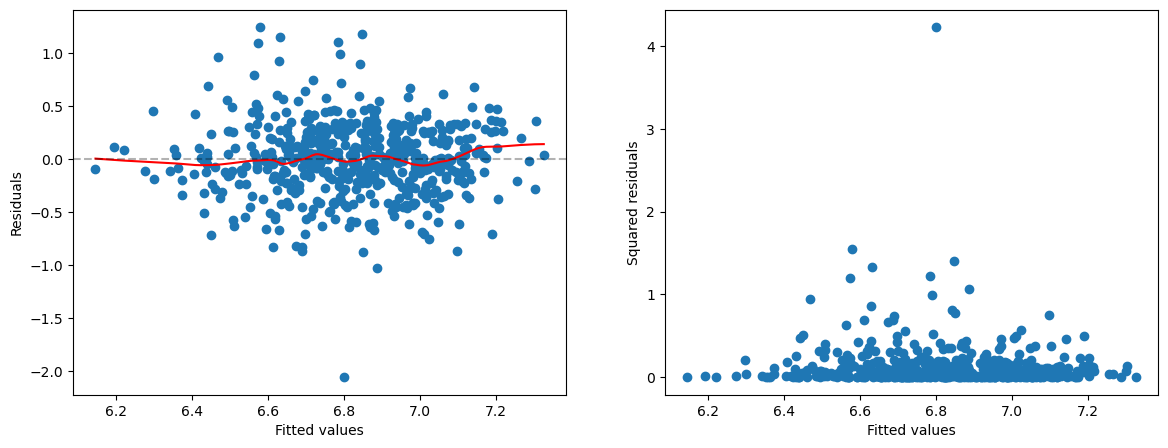

In [419]:
fig = plt.figure(figsize=(14,5))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)
ax1.scatter(reg7.fittedvalues,reg7.resid)
z1=lowess(reg7.resid,reg7.fittedvalues,frac=1./5)
ax1.plot(z1[:,0],z1[:,1],'red')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black',alpha=0.3,linestyle='--')
resid72=reg7.resid**2
ax2.scatter(reg7.fittedvalues,resid72)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Squared residuals')
plt.show()

**LSA 1**: The LOWESS smoothed plot of residuals against fitted values appears mostly flat, with only minor deviations at the extremes. This suggests that the relationship between the predictors and $lwage$ is approximately linear, satisfying the linearity assumption.

**LSA 2**: Residuals are generally centered around zero without systematic patterns, indicating that the expected value of the error term given the predictors is close to zero. This supports the assumption that $E(\epsilon|X) = 0$

**LSA 3**: The data is cross-sectional and lacks clustering or time structure, so this assumption is reasonably satisfied.

**LSA 4**: Visual inspection of residual shows some outliers but no severe skewness or heavy tails. Predictors such as $IQ$ and $KWW$ are bounded and roughly symmetric. Thus, this assumption is likely to hold.

**LSA 5**: VIF values are not excessively high, so multicollinearity does not pose a major concern.

**LSA 6**: The spread of residuals and squared residuals remains relatively consistent across the range of fitted values. There is no clear pattern of increasing or decreasing variance, suggesting that the constant variance assumption holds.



In [ ]:
y_test = test['lwage']
y_pred4 = reg4.predict(test)

# Step 5: Evaluate predictions via OLS: Actual ~ Predicted
results_df4 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred4})
eval_model4 = sm.OLS(results_df4['Actual'], sm.add_constant(results_df4['Predicted'])).fit()
rmfse4=np.sqrt(np.mean((y_test-y_pred4)**2))
mafe4=np.mean(np.abs(y_test-y_pred4))
print(rmfse4)
print(mafe4)


0.352587804735162
0.2717554699663611


In [302]:
print(eval_model4.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     63.77
Date:                Thu, 29 May 2025   Prob (F-statistic):           8.78e-13
Time:                        18:52:00   Log-Likelihood:                -44.318
No. Observations:                 124   AIC:                             92.64
Df Residuals:                     122   BIC:                             98.28
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3989      1.150     -2.087      0.0

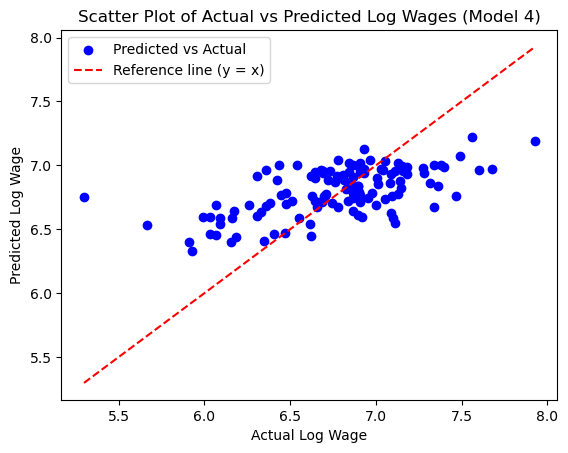

In [ ]:
y_pred4= reg4.predict(test)

# Create DataFrame with actual and predicted values
results_df4 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred10})

# Create scatter plot
plt.scatter(results_df10['Actual'], results_df4['Predicted'], color='blue', label='Predicted vs Actual')

# Add reference line y = x
min_val = min(results_df4['Actual'].min(), results_df4['Predicted'].min())
max_val = max(results_df4['Actual'].max(), results_df4['Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Reference line (y = x)')

# Add labels and title
plt.xlabel('Actual Log Wage')
plt.ylabel('Predicted Log Wage')
plt.title('Scatter Plot of Actual vs Predicted Log Wages (Model 4)')
plt.legend()

# Show plot
plt.show()


In [ ]:
y_test = test['lwage']
y_pred7 = reg7.predict(test)

# Step 5: Evaluate predictions via OLS: Actual ~ Predicted
results_df7 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred7})
eval_model7 = sm.OLS(results_df7['Actual'], sm.add_constant(results_df7['Predicted'])).fit()
rmfse7=np.sqrt(np.mean((y_test-y_pred7)**2))
mafe7=np.mean(np.abs(y_test-y_pred7))
print(rmfse7)
print(mafe7)


0.3546500850379083
0.2711539023450769


In [ ]:
print(eval_model7.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     58.66
Date:                Thu, 29 May 2025   Prob (F-statistic):           4.94e-12
Time:                        12:39:31   Log-Likelihood:                -46.047
No. Observations:                 124   AIC:                             96.09
Df Residuals:                     122   BIC:                             101.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5782      1.091     -1.446      0.1

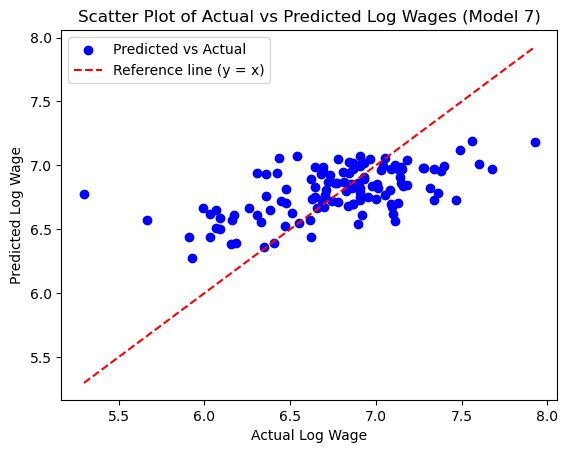

In [323]:
y_pred7 = reg7.predict(test)

# Create DataFrame with actual and predicted values
results_df7 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred7})

# Create scatter plot
plt.scatter(results_df7['Actual'], results_df7['Predicted'], color='blue', label='Predicted vs Actual')

# Add reference line y = x
min_val = min(results_df7['Actual'].min(), results_df7['Predicted'].min())
max_val = max(results_df7['Actual'].max(), results_df7['Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Reference line (y = x)')

# Add labels and title
plt.xlabel('Actual Log Wage')
plt.ylabel('Predicted Log Wage')
plt.title('Scatter Plot of Actual vs Predicted Log Wages (Model 7)')
plt.legend()

# Show plot
plt.show()

In [344]:
test['hourssqrt']=np.sqrt(test['hours'])
y_test = test['lwage']
test['spline_educ_15']=np.maximum(0, test['educ'] - 15)
test['spline_age_35']=np.maximum(0, test['age'] - 35)
y_pred10 = reg10.predict(test)


# Step 5: Evaluate predictions via OLS: Actual ~ Predicted
results_df10 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred10})
eval_model10= sm.OLS(results_df10['Actual'], sm.add_constant(results_df10['Predicted'])).fit()
rmfse10=np.sqrt(np.mean((y_test-y_pred10)**2))
mafe10=np.mean(np.abs(y_test-y_pred10))
print(rmfse10)
print(mafe10)


0.3426585569535313
0.26298995851257057


In [345]:
print(eval_model10.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     79.65
Date:                Thu, 29 May 2025   Prob (F-statistic):           5.52e-15
Time:                        19:53:24   Log-Likelihood:                -39.235
No. Observations:                 124   AIC:                             82.47
Df Residuals:                     122   BIC:                             88.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0443      1.101     -2.765      0.0

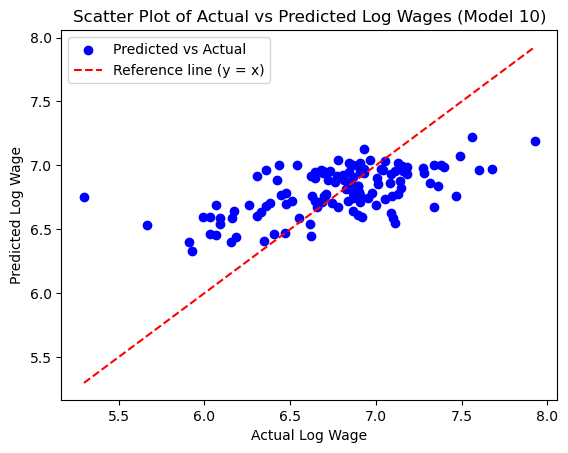

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Example: replace with your actual test data and model
y_test = test['lwage']
y_pred10 = reg10.predict(test)

# Create DataFrame with actual and predicted values
results_df10 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred10})

# Create scatter plot
plt.scatter(results_df10['Actual'], results_df10['Predicted'], color='blue', label='Predicted vs Actual')

# Add reference line y = x
min_val = min(results_df10['Actual'].min(), results_df10['Predicted'].min())
max_val = max(results_df10['Actual'].max(), results_df10['Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Reference line (y = x)')

# Add labels and title
plt.xlabel('Actual Log Wage')
plt.ylabel('Predicted Log Wage')
plt.title('Scatter Plot of Actual vs Predicted Log Wages (Model 10)')
plt.legend()

# Show plot
plt.show()


In [ ]:

# Define the data
threemodels = {
    'Model': [4,7,10],
    'RMSFE': [rmfse4,rmfse7,rmfse10],
    'MAFE': [mafe4,mafe7,mafe10],
    'R²_adj': [eval_model4.rsquared_adj,eval_model7.rsquared_adj,eval_model10.rsquared_adj],
    'p': [reg4.df_model,reg7.df_model,reg10.df_model]
}

# Create the DataFrame
df_three = pd.DataFrame(threemodels)

# Display the DataFrame
print(df_three)

   Model     RMSFE      MAFE    R²_adj    p
0      4  0.357389  0.272077  0.314608  8.0
1      7  0.354650  0.271154  0.319181  9.0
2     10  0.346578  0.268261  0.372230  8.0


In [342]:
y_predextra = regextra.predict(test)

# Step 5: Evaluate predictions via OLS: Actual ~ Predicted
results_dfextra = pd.DataFrame({'Actual': y_test, 'Predicted': y_predextra})
eval_modelextra= sm.OLS(results_dfextra['Actual'], sm.add_constant(results_dfextra['Predicted'])).fit()

print(eval_modelextra.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     70.77
Date:                Thu, 29 May 2025   Prob (F-statistic):           8.91e-14
Time:                        19:45:19   Log-Likelihood:                -42.025
No. Observations:                 124   AIC:                             88.05
Df Residuals:                     122   BIC:                             93.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7223      1.130     -2.410      0.0

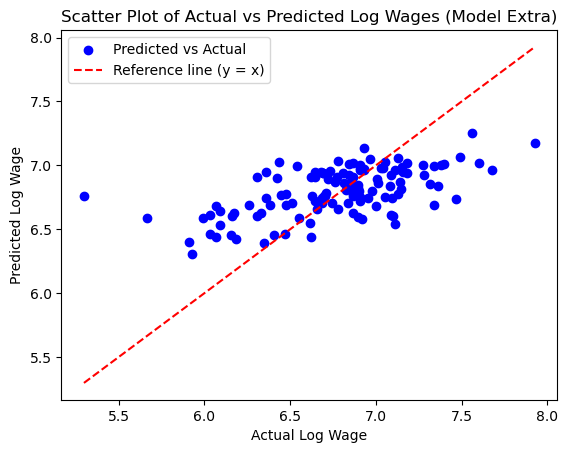

In [ ]:

# Create DataFrame with actual and predicted values
results_dfextra = pd.DataFrame({'Actual': y_test, 'Predicted': y_predextra})

# Create scatter plot
plt.scatter(results_dfextra['Actual'], results_dfextra['Predicted'], color='blue', label='Predicted vs Actual')

# Add reference line y = x
min_val = min(results_dfextra['Actual'].min(), results_dfextra['Predicted'].min())
max_val = max(results_dfextra['Actual'].max(), results_dfextra['Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Reference line (y = x)')

# Add labels and title
plt.xlabel('Actual Log Wage')
plt.ylabel('Predicted Log Wage')
plt.title('Scatter Plot of Actual vs Predicted Log Wages (Model Extra)')
plt.legend()

# Show plot
plt.show()